# Requirements check

In [11]:
import sys
print(sys.version)

3.9.7 | packaged by conda-forge | (default, Sep 29 2021, 19:20:16) [MSC v.1916 64 bit (AMD64)]


# Install dependencies

In [3]:
# cell A: which Python executable and environment
import sys, os
print("sys.executable:", sys.executable)
print("sys.version:", sys.version.replace('\n',' '))
print("PATH contains CUDA:", any("CUDA" in p or "cudnn" in p.lower() for p in os.environ.get("PATH","").split(os.pathsep)))


sys.executable: C:\Users\omirz\anaconda3\envs\sber_inputs\python.exe
sys.version: 3.9.7 | packaged by conda-forge | (default, Sep 29 2021, 19:20:16) [MSC v.1916 64 bit (AMD64)]
PATH contains CUDA: True


In [4]:
# cell B: torch diagnostics (safe if torch absent)
try:
    import torch
    print("torch.__version__:", torch.__version__)
    print("torch.version.cuda:", torch.version.cuda)
    print("torch.cuda.is_available():", torch.cuda.is_available())
    print("cuda device count:", torch.cuda.device_count())
    if torch.cuda.is_available():
        print("device name:", torch.cuda.get_device_name(0))
except Exception as e:
    print("import torch failed / torch not found:", e)


torch.__version__: 2.5.1
torch.version.cuda: 12.1
torch.cuda.is_available(): True
cuda device count: 1
device name: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [5]:
import torch

torch.cuda.is_available()

True

In [1]:
!pip install -r requirements.txt

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)


ERROR: Ignored the following versions that require a different python version: 1.7.0 Requires-Python >=3.10; 1.7.0rc1 Requires-Python >=3.10; 1.7.1 Requires-Python >=3.10; 1.7.2 Requires-Python >=3.10; 1.8.0rc1 Requires-Python >=3.11
ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


## Imports

In [1]:
from utils.constants import (
    CATEGORY_MAP,
    BEST_PREDICTORS_FOR_INDEX
)
from utils.utils import (
    plot_known_feature_value,
    plot_graphics_for_each_ts,
    get_month_beginnings
)
import numpy as np
from utils.parametrized_values import (
    form_df_future,
    load_models,
    form_input_to_forecasting,
    train_model_and_eval_res,
    get_prediction_for_ts,
    df_combined,
    macro_data
)
from utils.cluster_forecast import ClusterForecaster
from itertools import combinations
from typing import Type, Literal, Any
from darts import TimeSeries
import pandas as pd
import os
from dateutil.relativedelta import relativedelta

import warnings
warnings.filterwarnings('ignore')

Index(['Unnamed: 0', 'USDRUB', 'Кукуруза', 'Молоко сырое',
       'Мясо птицы бройлеров в живом весе ',
       'Мясо крупного рогатого скота в живом весе ', 'Подсолнечник',
       'Пшеница 1-го класса', 'Пшеница 3-го класса', 'Пшеница 5-го класса',
       'Сахар (средняя цена по России)', 'Свинина в живом весе',
       'Соевое масло', 'Соевый шрот', 'Соя', 'Яйцо товарное',
       'Подсолнечное масло наливом (мировые цены)',
       'Бутилированное подсолнечное масло (рафинированное)',
       'Подсолнечный шрот ', 'Колбасы сырокопченые', 'Баранина в живом весе',
       'Баранина в убойном весе ', 'Какао-бобы (USD)', 'Какао-бобы',
       'Подсолнечное масло (наливом) не бутилированное, нерафинированное ',
       'Кокосовое масло (USD) ', 'Кокосовое масло ', 'Пальмовое масло (USD)',
       'Пальмовое масло ', 'Табак (USD)', 'Табак', 'Пшеница 4-го класса',
       'Минтай б/г, Владивосток руб./кг', 'Минтай б/г, Китай C&F $/т',
       'Сельдь н/р, Владивосток руб./кг', 'Огурцы тепличные, руб.

---
## TODO

Важные общие замечания:
1) делаем на python 3.9.7 сразу, чтобы у СБЕРа не было траблов с установкой (если что-то не получится, то проблем другую версию, но лучше, чтобы у них запустились) 
2) Им нужна возможность задавать больше 1го Инпута. Причем, лучше хуево, чем этого функционала вообще не будет. 
3) Прогнозируем мы все ряды (в том числе макро) 
4) В ряду, который является инпутом на визуализации надо подменять независимый прогноз на введённые значения (сейчас этого нет) 
5) Возможно стоит сделать проще и убрать часть предикторов - это довольно сложный функционал, который может расшатывать модель. 
6) Лучше сделать так, чтобы мы задавали только будущее значение и дату, а пропуск между последним доступным значением ряда заполнялся автоматом линейно. 


Общая архитектура: 
0) Датасеты - макро и отрасли (совмещённый АПК и Химия)
1) Общая предобработка - выделение кластеров (скрытая - просто забираем json )

2) Свёртка кластеров в индексы
3) Прогноз индексов и макро параметров
4) Расшивка индексов

Описание архитектуры отдельных частей: 
2) Свёртка кластеров в индексы - 
сначала нормализуешь ряды в кластере, потом берешь среднее по ним. Все

3) Прогноз индексов и макро: 
Сценарий 1: (univariate модель)
Каждый индекс или макро предсказывается своей моделью. Для индексов макропараметры являются past _covariates. 

Макропараметры можно предсказывать отдельно друг от друга, либо тоже добавлять в ковариаты друг другу - как выйдет, но лучше второе. 

Сценарий 2: (многомерная модель tft, Хронос или Random Forest) 
В этом случае мы учим ОДНУ модель для индексов и макро. 

Либо учим отдельно модель для макро, а их прогноз используем для Второй модели индексов как past_covariates. 

Не надо плодить на каждый ряд свою модель. 

Предикторы можно даже не использовать. 

4) Расшивка: 
Сценарий1: смотрим какие процентные изменения в прогнозе на индекс. Переносим такие же на сам ряд (можно даже обратную нормализацию не делать в таком случае) 

Сценарий 2: Можно то же самое сделать через линейную регрессию ряда по индексу. 

Сценарий 3: 
Простенькая multivariate модель для каждого кластера, в которую мы запихивает прогноз индекса как future covariate (но это не обязательно)

Лучше сделать сначала по 1му сценарию. Потом допилим остальное, если будет возможность.

---
## Global parameters setting

In [2]:
print(f"Available columns to predict: {df_combined.columns}, {macro_data.columns}")

Available columns to predict: Index(['Unnamed: 0', 'USDRUB', 'Кукуруза', 'Молоко сырое',
       'Мясо птицы бройлеров в живом весе ',
       'Мясо крупного рогатого скота в живом весе ', 'Подсолнечник',
       'Пшеница 1-го класса', 'Пшеница 3-го класса', 'Пшеница 5-го класса',
       ...
       'Апатитовый концетрат (FOB Morocco)_norm',
       'Аммиак (FOB Черное море)_norm',
       'Аммиачная селитра (FOB Черное море)_norm',
       'Хлорид калия (CFR Ю-В Азия)_norm',
       'Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия_norm',
       'Метанол_norm', 'Бензол, CFR Япония_norm', 'Этилен, CFR Китай_norm',
       'dip_norm_sum', 'bump_norm_sum'],
      dtype='object', length=110), Index(['Инфляция - Рост индекса цен производителей (RUB, eop PPI),',
       'Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),',
       'Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),',
       'Ключевая ставка, годовых', 'Инфляция

## Описание параметров запуска

### Основные параметры прогнозирования
- `PREDICTION_HORIZON = 12` - горизонт прогнозирования (месяцев)
- `PREDICTOR_LAG = 12` - лаг предикторов

### Режимы работы и даты
- `IS_BACKTEST: bool = True` - режим бэктеста (True - тестирование на исторических данных, False - реальный прогноз)
- `BACKTEST_DATE` - дата начала бэктеста
- `SINGLE_DATAPOINT_TO_PRED = "2026-04-14"` - целевая дата для прогноза

### Параметры моделей
- `TARGET_COL_SUFFIX = "_sum"` - суффикс целевой переменной
- `MODEL_NAME_FOR_FORECASTER = "nbeats"` - тип модели для прогнозирования
- `USE_FUTURE_COV` - использование будущих ковариат (автоматически определяется по типу модели)

### Временные параметры
- `FUTURE_DATE` - будущая дата значений
- `train_end` - конец обучающего периода
- `past_idx` - даты исторических данных для обучения
- `future_idx` - даты будущего периода для прогноза

### Параметры внешних факторов
- `FUTURE_FORECASTER_TS_NAME = "Инфляция, г/г"` - название макроэкономического показателя
- `FUTURE_FORECASTER_TS_VALUES` - известные будущие значения макропоказателя

### Управление моделями
- `MODEL_SAVE_PATH` - шаблон пути для сохранения моделей
- `PERSIST_MODEL = True` - флаг сохранения моделей на диск
- `REFIT_MODEL = True` - флаг переобучения моделей

In [3]:
SINGLE_DATAPOINT_TO_PRED = "2025-05-01"

IS_BACKTEST: bool = df_combined.index[-1] <= pd.to_datetime(SINGLE_DATAPOINT_TO_PRED)
BACKTEST_PREDICTION_RANGE = 36 if IS_BACKTEST else 0

new_dates = pd.date_range(start=df_combined.index[-1] + pd.DateOffset(months=1),
                      end=SINGLE_DATAPOINT_TO_PRED,
                      freq='MS') if not IS_BACKTEST else \
            pd.date_range(start=pd.to_datetime(SINGLE_DATAPOINT_TO_PRED) - pd.DateOffset(months=BACKTEST_PREDICTION_RANGE) + pd.DateOffset(months=1),
                      end=SINGLE_DATAPOINT_TO_PRED,
                      freq='MS')

PREDICTION_HORIZON = len(new_dates) if not IS_BACKTEST else BACKTEST_PREDICTION_RANGE

FUTURE_VALUES = {
    # "Кукуруза": 0.0,
    # "Пшеница 1-го класса": 0.0,
    # "Пшеница 3-го класса": 0.0,
    # "Пшеница 4-го класса": 0.0,
    # "Пшеница 5-го класса": 0.0,
    # "Пшеница 12,5% FOB Ново, $ т": 0.0,
    "Подсолнечник": 22.1,
    # "Соя": 0.0,
    # "Рапс, руб. т": 0.0,
    # # Oils & Meals
    # "Подсолнечное масло наливом (мировые цены)": 0.0,
    # "Бутилированное подсолнечное масло (рафинированное)": 0.0,
    # "Подсолнечное масло (наливом) не бутилированное, нерафинированное ": 0.0,
    # "Подсолнечное масло (наливом) не бутилированное, не": 0.0,
    # "Подсолнечный шрот ": 0.0,
    # "Соевое масло": 0.0,
    # "Соевый шрот": 0.0,
    # "Рапсовое масло EU, $ т": 0.0,
    # "Кокосовое масло ": 0.0,
    # "Пальмовое масло ": 0.0,
    # # Livestock
    # "Молоко сырое": 0.0,
    # "Мясо птицы бройлеров в живом весе ": 0.0,
    # "Мясо крупного рогатого скота в живом весе ": 0.0,
    # "Свинина в живом весе": 0.0,
    # "Баранина в живом весе": 0.0,
    # "Баранина в убойном весе ": 0.0,
    # "Яйцо товарное": 0.0,
    # # Processed meat
    # "Колбасы сырокопченые": 0.0,
    # "Колбасы вареные": 0.0,
    # # Fish
    # "Минтай б г, Владивосток руб. кг": 0.0,
    # "Минтай б г, Китай C&F $ т": 0.0,
    # "Сельдь н р, Владивосток руб. кг": 0.0,
    # # Vegetables
    # "Огурцы тепличные, руб. кг": 0.0,
    # "Томаты тепличные, руб. кг": 0.0,
    # # Other
    # "Сахар (средняя цена по России)": 0.0,
    # "Мука пшеничная, руб. т": 0.0,
    # # Stimuli crops
    # "Какао-бобы": 0.0,
    # "Табак": 0.0,
    # # Chemicals - dip
    # "Карбамид (FOB Южный)": 0.0,
    # "Моноаммонийфосфат, MAP (FOB Балтика)": 0.0,
    # "Апатитовый концетрат (FOB Morocco)": 0.0,
    # "Аммиак (FOB Черное море)": 0.0,
    # "Аммиачная селитра (FOB Черное море)": 0.0,
    # "Хлорид калия (CFR Ю-В Азия)": 0.0,
    # # Chemicals - bump
    # "Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия": 0.0,
    # "Метанол": 0.0,
    # "Бензол, CFR Япония": 0.0,
    # "Этилен, CFR Китай": 0.0,
    # # macros
    # "Инфляция - Рост индекса цен производителей (RUB, eop PPI),": 0.0,
    # "Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),": 0.0,
    # "Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),": 0.0,
    "Ключевая ставка, годовых": 18.0,
    "Инфляция, г/г": 12.0,
    # "USDRUB": 0.0
}
FUTURE_FORECASTER_TS_NAME = FUTURE_VALUES.keys()  # ["Подсолнечник", "Ключевая ставка, годовых", "Инфляция, г/г"]
FUTURE_FORECASTER_TS_VALUES_RAW = FUTURE_VALUES.values()

BACKTEST_DATE = df_combined.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON*2)
TS_FREQUENCY = "MS"
train_end = BACKTEST_DATE if not IS_BACKTEST else pd.to_datetime(SINGLE_DATAPOINT_TO_PRED) - pd.DateOffset(months=BACKTEST_PREDICTION_RANGE)
past_idx = pd.date_range(start=pd.to_datetime(SINGLE_DATAPOINT_TO_PRED) - pd.DateOffset(months=BACKTEST_PREDICTION_RANGE*2) + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON,
                           freq=TS_FREQUENCY)
future_idx = pd.date_range(start=past_idx[-1] + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON,
                           freq=TS_FREQUENCY)
PERSIST_MODEL = True
REFIT_MODEL = True

PREDICTOR_LAG = 12
MODEL_SAVE_PATH = "{model_name}_dataset/{model_name}_for_{category_name}" + f"_{BACKTEST_PREDICTION_RANGE}" if IS_BACKTEST else  "{model_name}_dataset/{model_name}_for_{category_name}"
TARGET_COL_SUFFIX = "_norm_sum"
MODEL_NAME_FOR_FORECASTER: Literal["tftmodel", "nbeats", "naiveseasonal", "randomforest"] = "randomforest"
USE_FUTURE_COV = MODEL_NAME_FOR_FORECASTER in ("tftmodel", "randomforest", "chronos")

if IS_BACKTEST:
    df_updated = df_combined
    macro_updated = macro_data
    FUTURE_FORECASTER_TS_VALUES = []
    for ts_name in FUTURE_FORECASTER_TS_NAME: # TODO: rewrite to np.linnspace
        df_target = df_updated if ts_name in df_updated.columns else macro_updated
        FUTURE_FORECASTER_TS_VALUES.append(df_target[df_target.index > train_end][ts_name].values)
else:
    df_updated, macro_updated, FUTURE_FORECASTER_TS_VALUES = form_df_future(new_dates,
                                                                           FUTURE_FORECASTER_TS_NAME,
                                                                           FUTURE_FORECASTER_TS_VALUES_RAW,
                                                                           PREDICTION_HORIZON
                                                                       )

In [7]:
FUTURE_VALUES = {
    # "Кукуруза": 0.0,
    # "Пшеница 1-го класса": 0.0,
    # "Пшеница 3-го класса": 0.0,
    # "Пшеница 4-го класса": 0.0,
    # "Пшеница 5-го класса": 0.0,
    # "Пшеница 12,5% FOB Ново, $ т": 0.0,
    "Подсолнечник": 22.1,
    # "Соя": 0.0,
    # "Рапс, руб. т": 0.0,
    # # Oils & Meals
    # "Подсолнечное масло наливом (мировые цены)": 0.0,
    # "Бутилированное подсолнечное масло (рафинированное)": 0.0,
    # "Подсолнечное масло (наливом) не бутилированное, нерафинированное ": 0.0,
    # "Подсолнечное масло (наливом) не бутилированное, не": 0.0,
    # "Подсолнечный шрот ": 0.0,
    # "Соевое масло": 0.0,
    # "Соевый шрот": 0.0,
    # "Рапсовое масло EU, $ т": 0.0,
    # "Кокосовое масло ": 0.0,
    # "Пальмовое масло ": 0.0,
    # # Livestock
    # "Молоко сырое": 0.0,
    # "Мясо птицы бройлеров в живом весе ": 0.0,
    # "Мясо крупного рогатого скота в живом весе ": 0.0,
    # "Свинина в живом весе": 0.0,
    # "Баранина в живом весе": 0.0,
    # "Баранина в убойном весе ": 0.0,
    # "Яйцо товарное": 0.0,
    # # Processed meat
    # "Колбасы сырокопченые": 0.0,
    # "Колбасы вареные": 0.0,
    # # Fish
    # "Минтай б г, Владивосток руб. кг": 0.0,
    # "Минтай б г, Китай C&F $ т": 0.0,
    # "Сельдь н р, Владивосток руб. кг": 0.0,
    # # Vegetables
    # "Огурцы тепличные, руб. кг": 0.0,
    # "Томаты тепличные, руб. кг": 0.0,
    # # Other
    # "Сахар (средняя цена по России)": 0.0,
    # "Мука пшеничная, руб. т": 0.0,
    # # Stimuli crops
    # "Какао-бобы": 0.0,
    # "Табак": 0.0,
    # # Chemicals - dip
    # "Карбамид (FOB Южный)": 0.0,
    # "Моноаммонийфосфат, MAP (FOB Балтика)": 0.0,
    # "Апатитовый концетрат (FOB Morocco)": 0.0,
    # "Аммиак (FOB Черное море)": 0.0,
    # "Аммиачная селитра (FOB Черное море)": 0.0,
    # "Хлорид калия (CFR Ю-В Азия)": 0.0,
    # # Chemicals - bump
    # "Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия": 0.0,
    # "Метанол": 0.0,
    # "Бензол, CFR Япония": 0.0,
    # "Этилен, CFR Китай": 0.0,
    # # macros
    # "Инфляция - Рост индекса цен производителей (RUB, eop PPI),": 0.0,
    # "Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),": 0.0,
    # "Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),": 0.0,
    "Ключевая ставка, годовых": 18.0,
    "Инфляция, г/г": 12.0,
    # "USDRUB": 0.0
}

In [10]:
FUTURE_VALUES.values()

dict_values([22.1, 18.0, 12.0])

---
## Known TS future

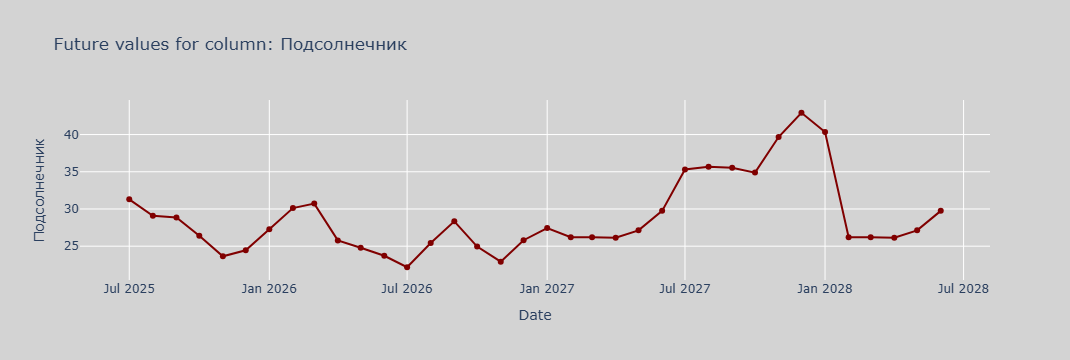

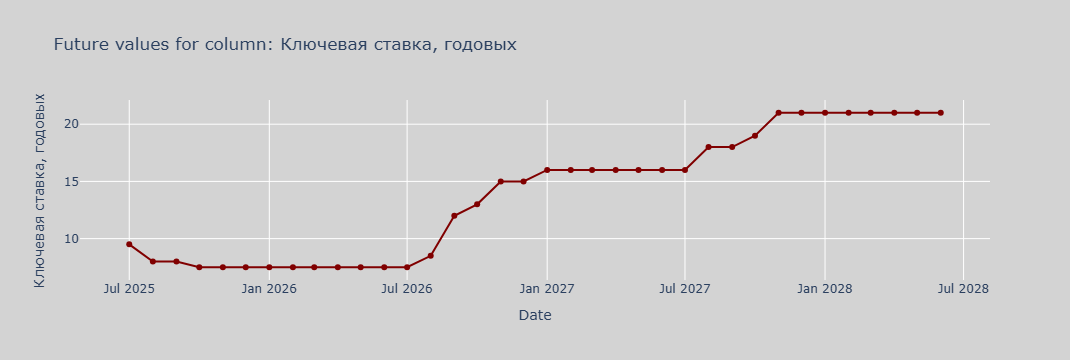

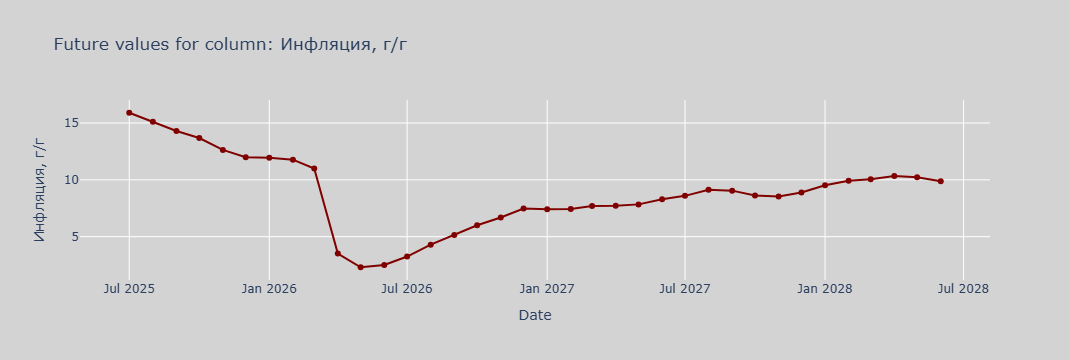

In [4]:
for ts_name, ts_val in zip(FUTURE_FORECASTER_TS_NAME, FUTURE_FORECASTER_TS_VALUES):
    plot_known_feature_value(ts_val,
                             ts_name,
                             pd.date_range(start=df_combined.index[-1] + pd.DateOffset(months=1) + pd.DateOffset(months=1),
                               periods=PREDICTION_HORIZON,
                               freq="MS"))

---
## Forecasting clusers

### predictions

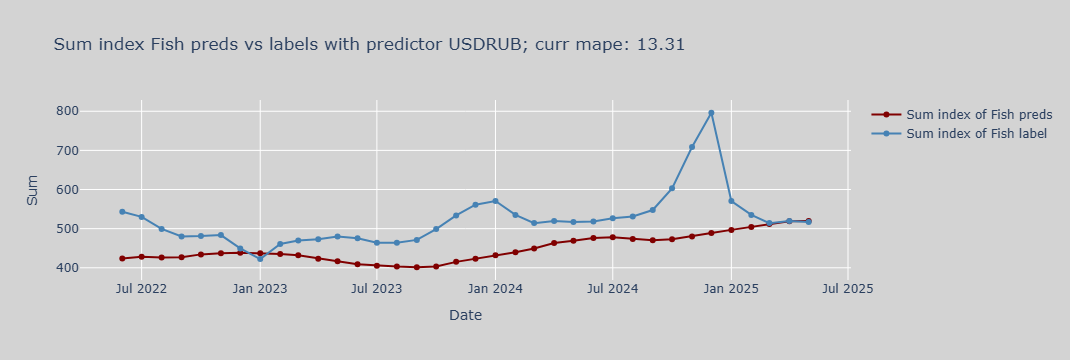

Saved forecaster to randomforest_dataset/randomforest_for_Fish_36.pkl and model to randomforest_dataset/randomforest_for_Fish_36_model.pth


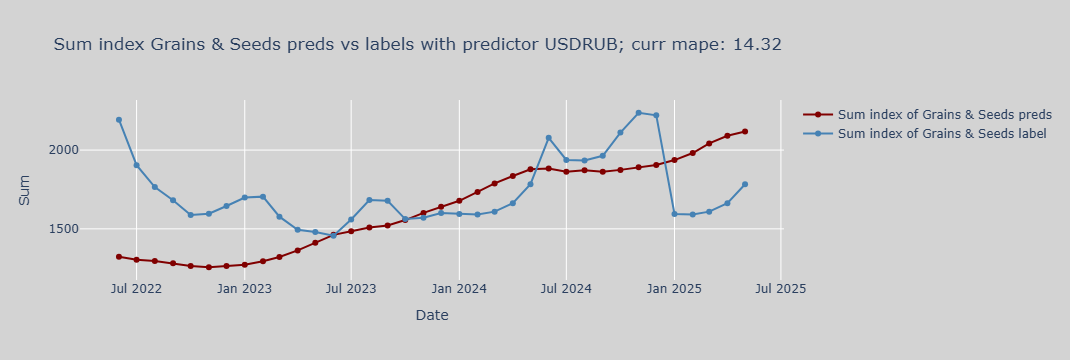

Saved forecaster to randomforest_dataset/randomforest_for_Grains & Seeds_36.pkl and model to randomforest_dataset/randomforest_for_Grains & Seeds_36_model.pth


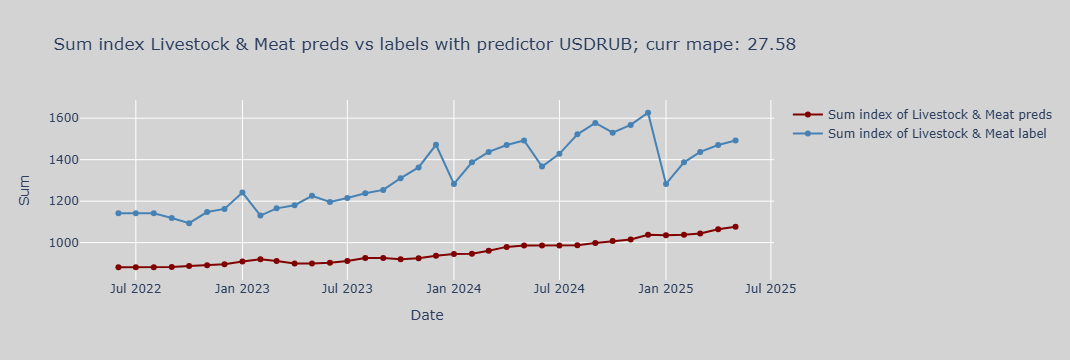

Saved forecaster to randomforest_dataset/randomforest_for_Livestock & Meat_36.pkl and model to randomforest_dataset/randomforest_for_Livestock & Meat_36_model.pth


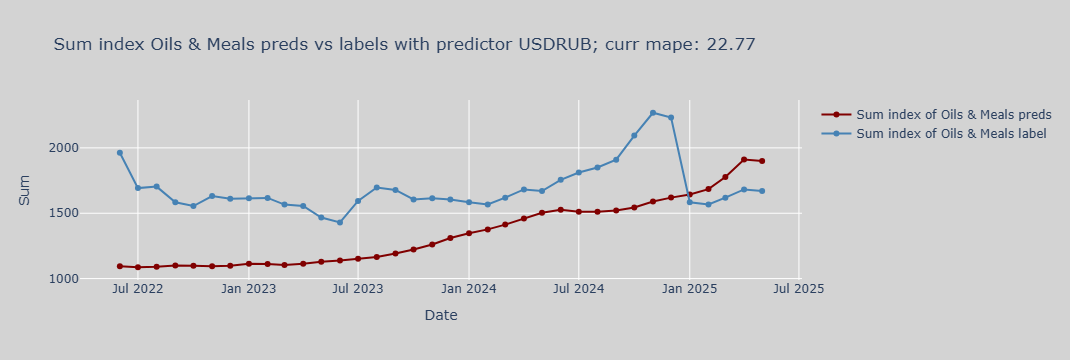

Saved forecaster to randomforest_dataset/randomforest_for_Oils & Meals_36.pkl and model to randomforest_dataset/randomforest_for_Oils & Meals_36_model.pth


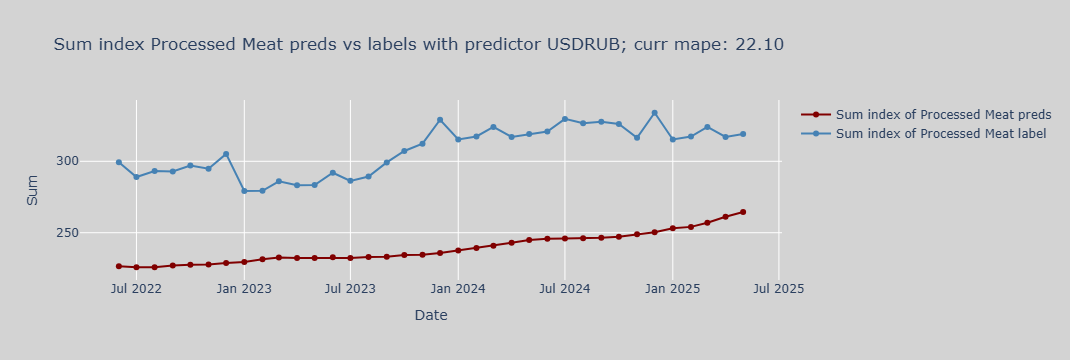

Saved forecaster to randomforest_dataset/randomforest_for_Processed Meat_36.pkl and model to randomforest_dataset/randomforest_for_Processed Meat_36_model.pth


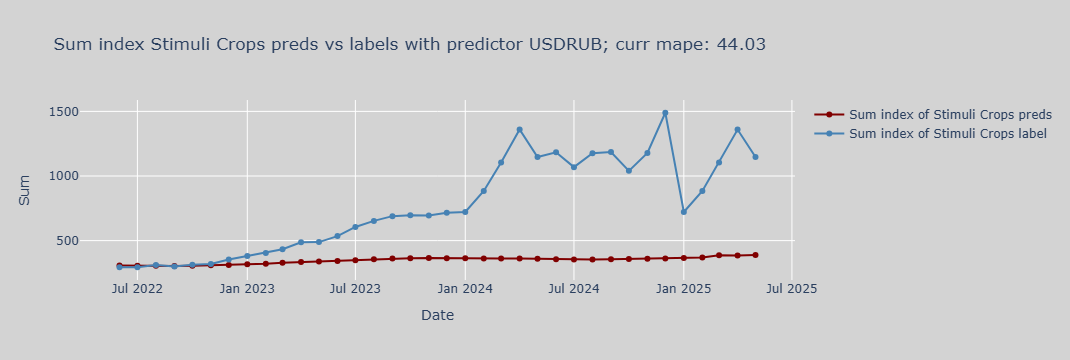

Saved forecaster to randomforest_dataset/randomforest_for_Stimuli Crops_36.pkl and model to randomforest_dataset/randomforest_for_Stimuli Crops_36_model.pth


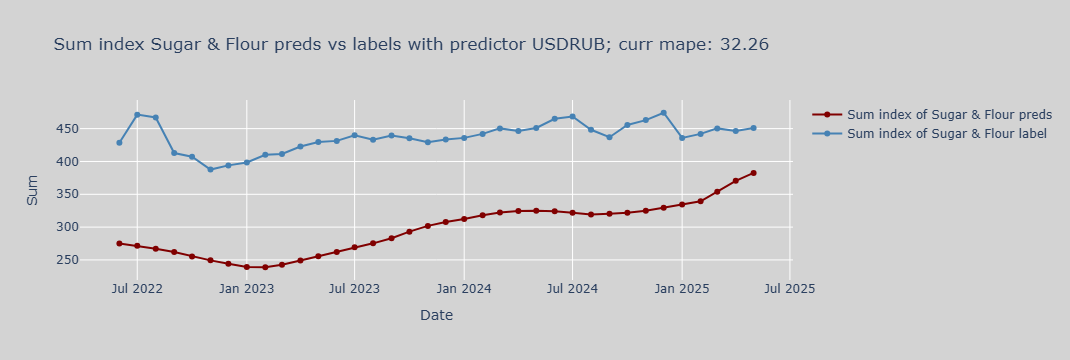

Saved forecaster to randomforest_dataset/randomforest_for_Sugar & Flour_36.pkl and model to randomforest_dataset/randomforest_for_Sugar & Flour_36_model.pth


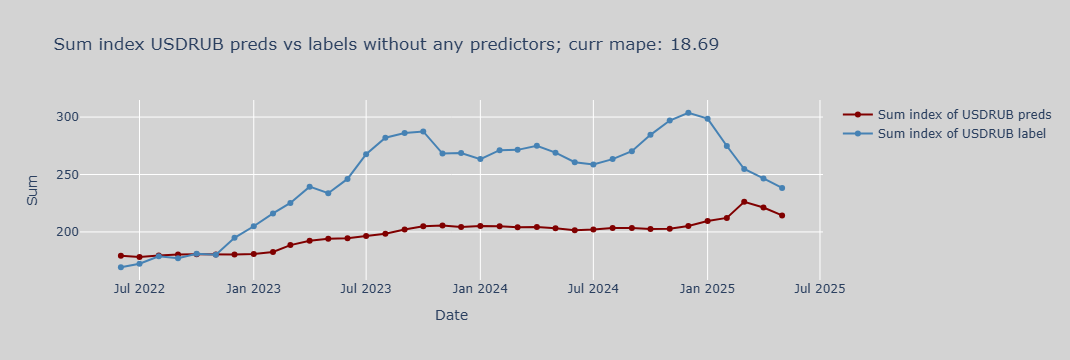

Saved forecaster to randomforest_dataset/randomforest_for_USDRUB_36.pkl and model to randomforest_dataset/randomforest_for_USDRUB_36_model.pth


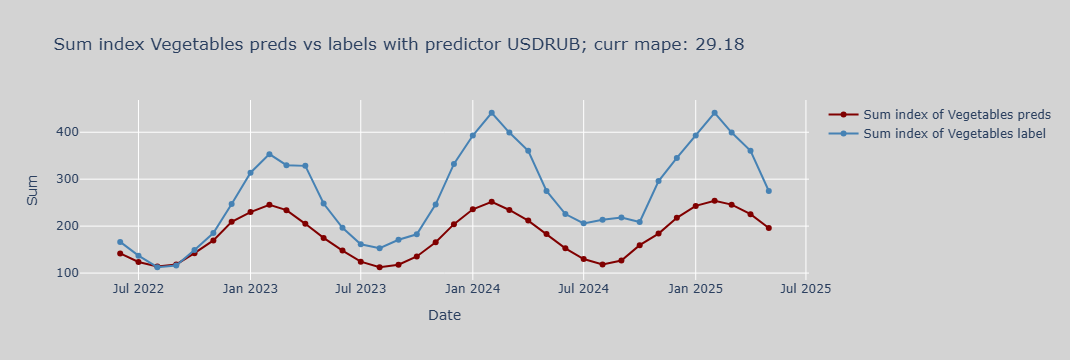

Saved forecaster to randomforest_dataset/randomforest_for_Vegetables_36.pkl and model to randomforest_dataset/randomforest_for_Vegetables_36_model.pth


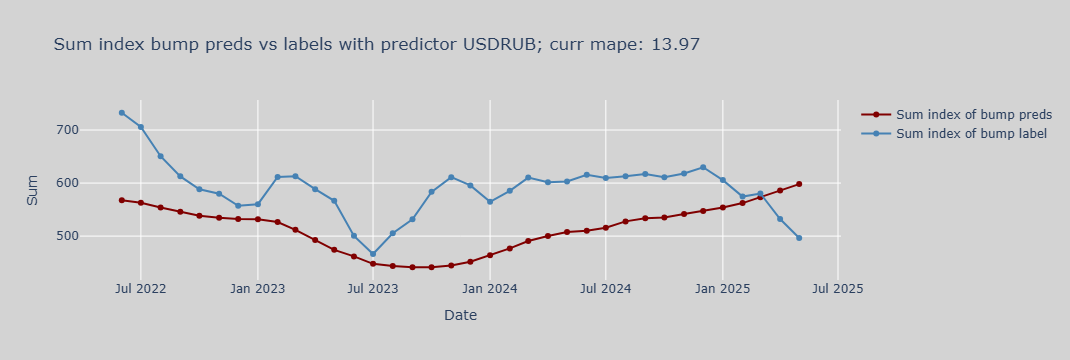

Saved forecaster to randomforest_dataset/randomforest_for_bump_36.pkl and model to randomforest_dataset/randomforest_for_bump_36_model.pth


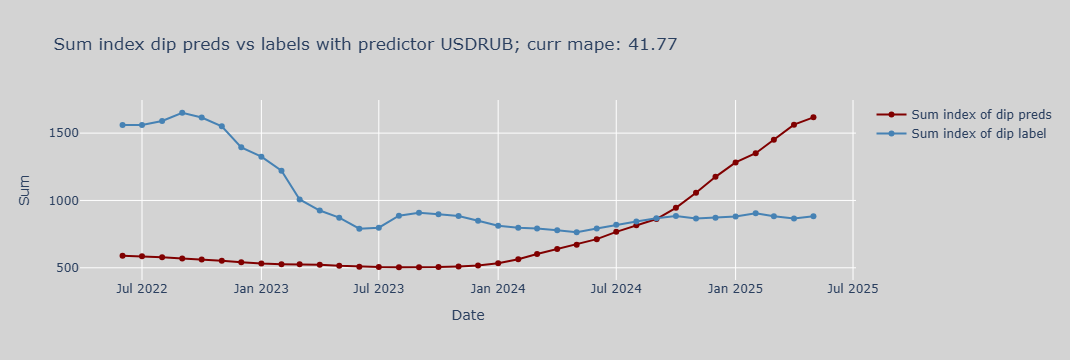

Saved forecaster to randomforest_dataset/randomforest_for_dip_36.pkl and model to randomforest_dataset/randomforest_for_dip_36_model.pth


ValueError: `actual_series` must be strictly positive to compute the MAPE.


Could not calculate mape for prediction due to `actual_series` must be strictly positive to compute the MAPE.


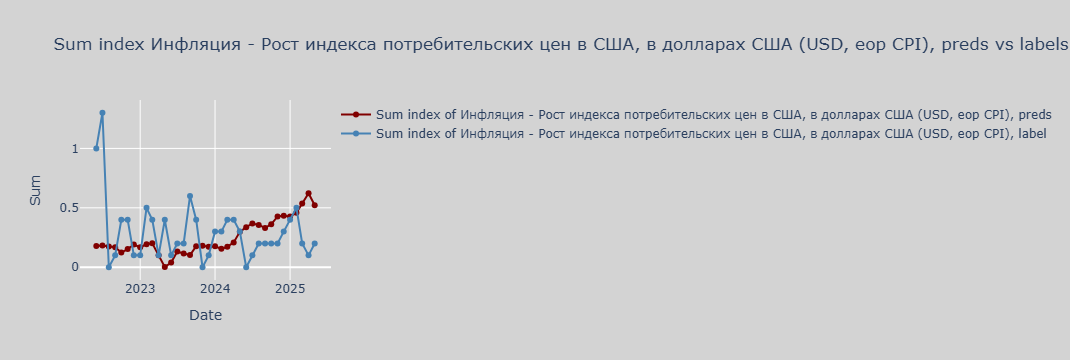

Saved forecaster to randomforest_dataset/randomforest_for_Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),_36.pkl and model to randomforest_dataset/randomforest_for_Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),_36_model.pth


ValueError: `actual_series` must be strictly positive to compute the MAPE.


Could not calculate mape for prediction due to `actual_series` must be strictly positive to compute the MAPE.


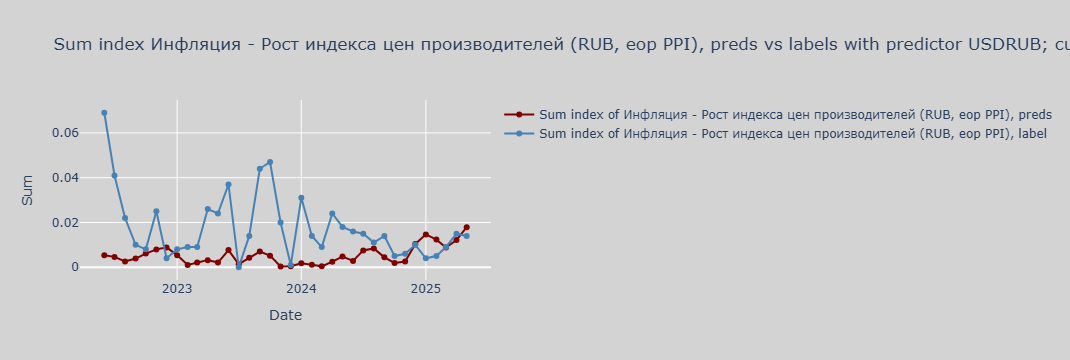

Saved forecaster to randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей (RUB, eop PPI),_36.pkl and model to randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей (RUB, eop PPI),_36_model.pth


ValueError: `actual_series` must be strictly positive to compute the MAPE.


Could not calculate mape for prediction due to `actual_series` must be strictly positive to compute the MAPE.


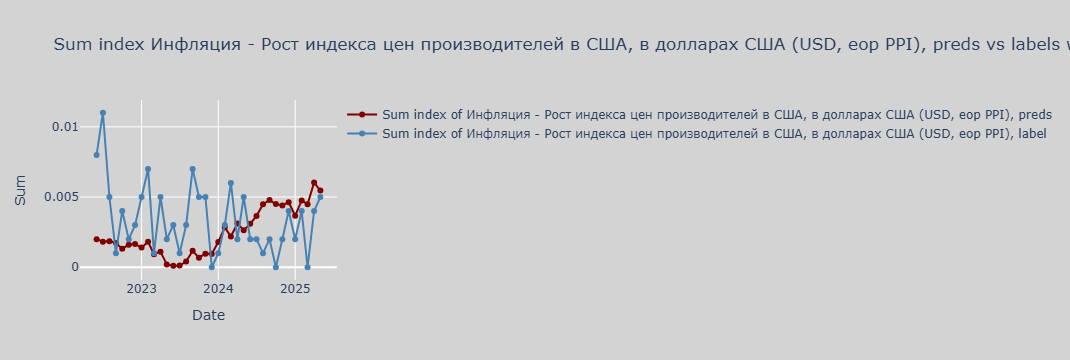

Saved forecaster to randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),_36.pkl and model to randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),_36_model.pth


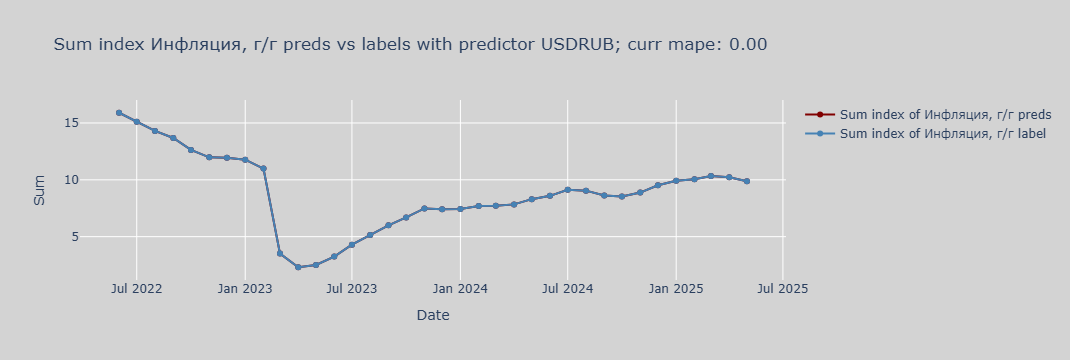

Saved forecaster to randomforest_dataset/randomforest_for_Инфляция, г_г_36.pkl and model to randomforest_dataset/randomforest_for_Инфляция, г_г_36_model.pth


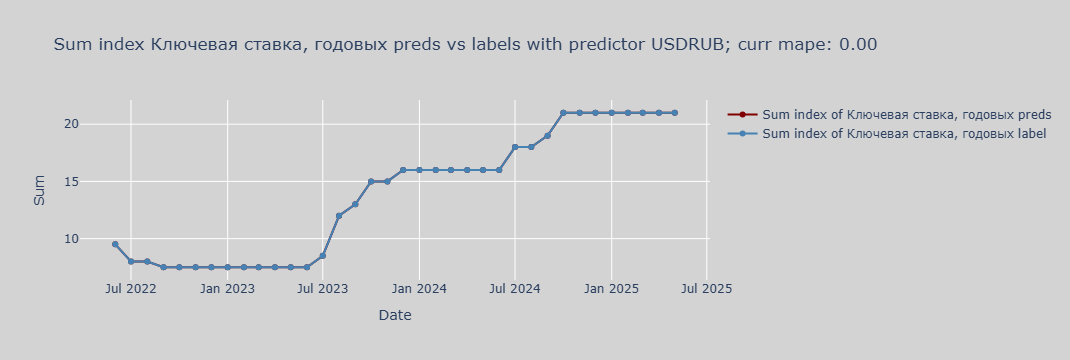

Saved forecaster to randomforest_dataset/randomforest_for_Ключевая ставка, годовых_36.pkl and model to randomforest_dataset/randomforest_for_Ключевая ставка, годовых_36_model.pth


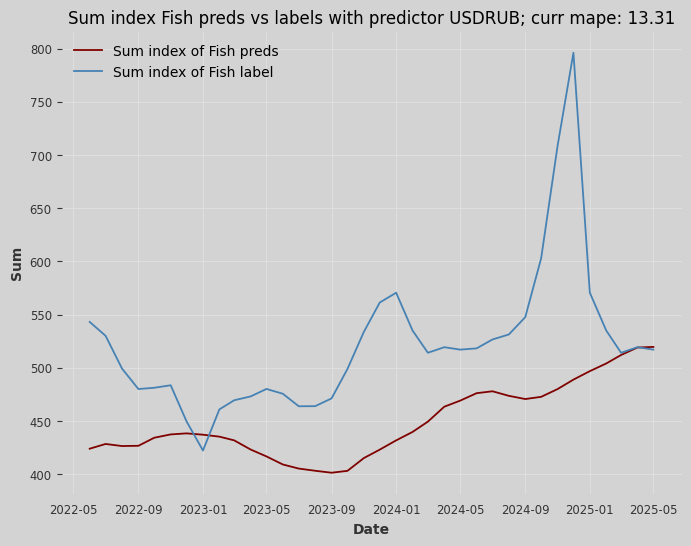

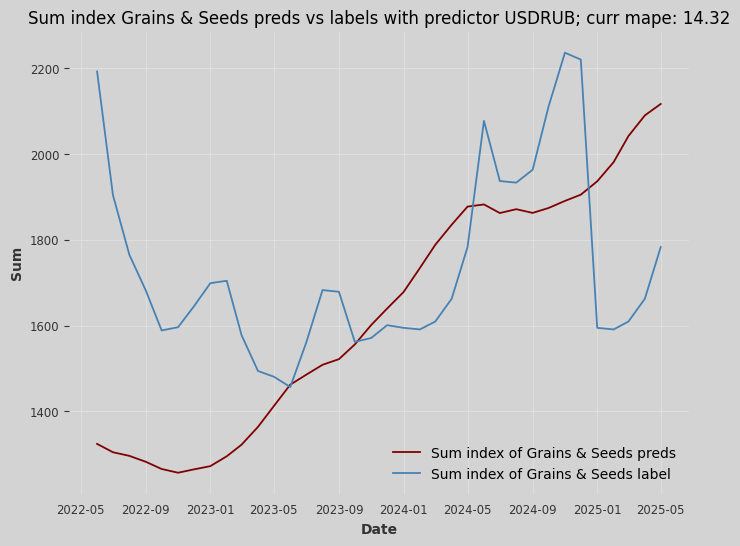

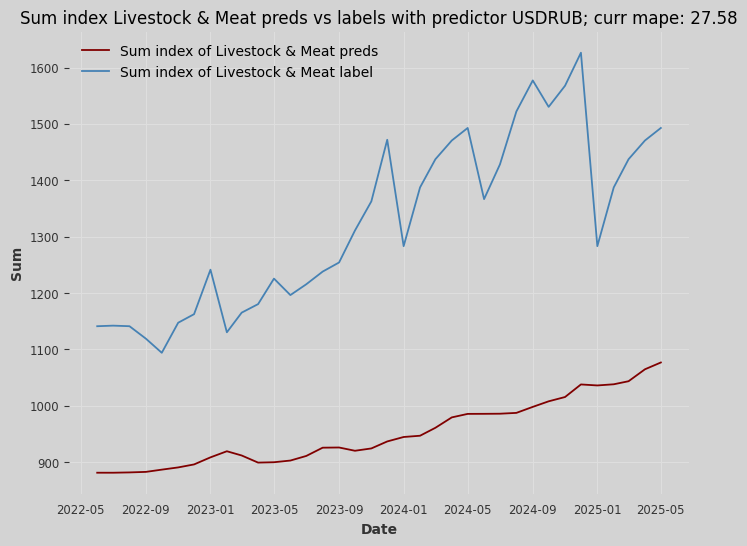

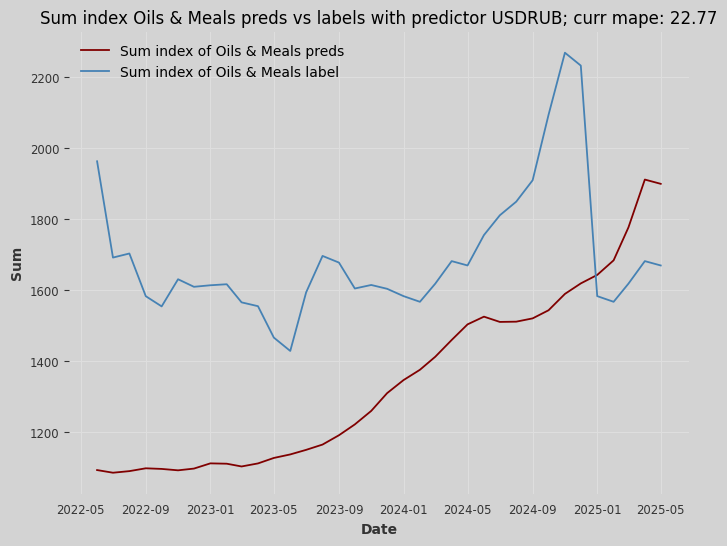

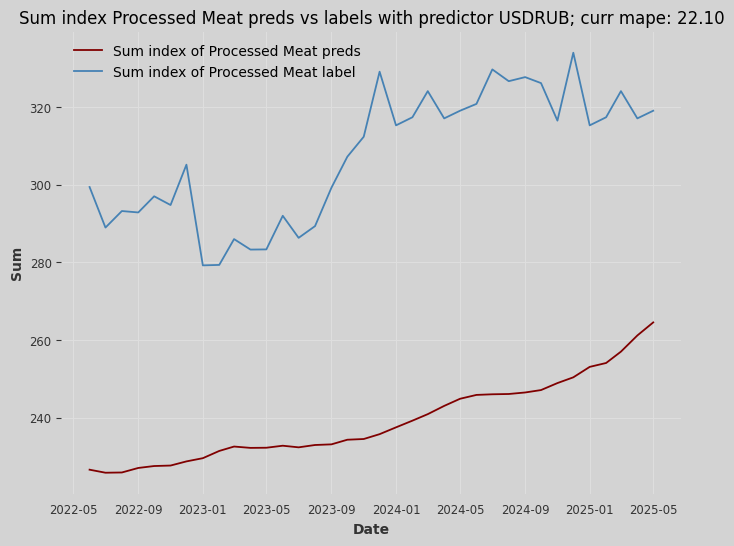

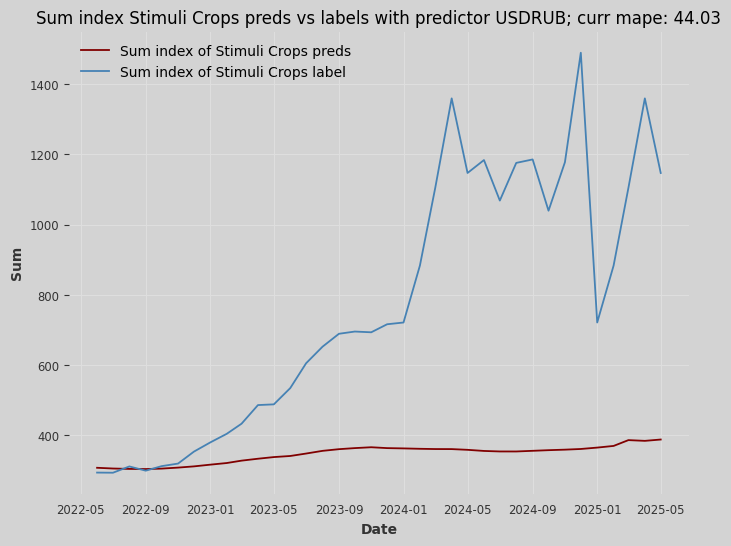

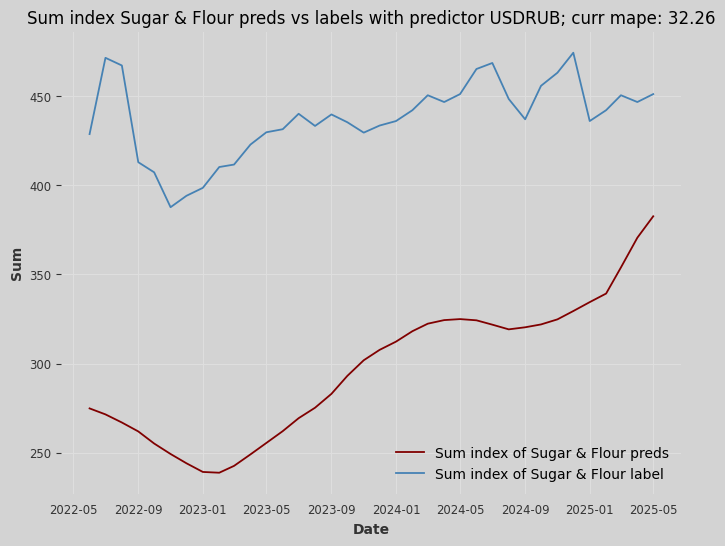

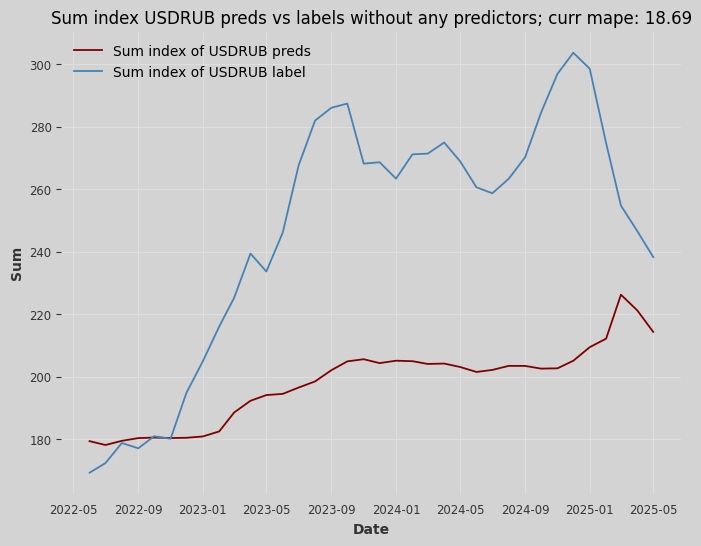

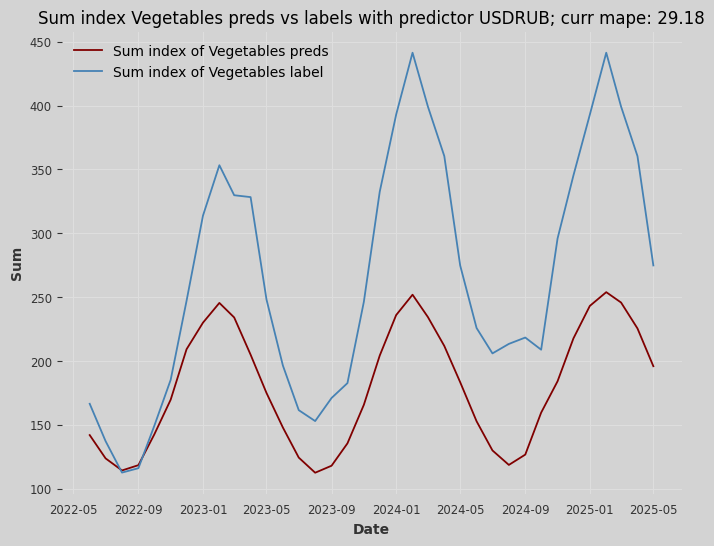

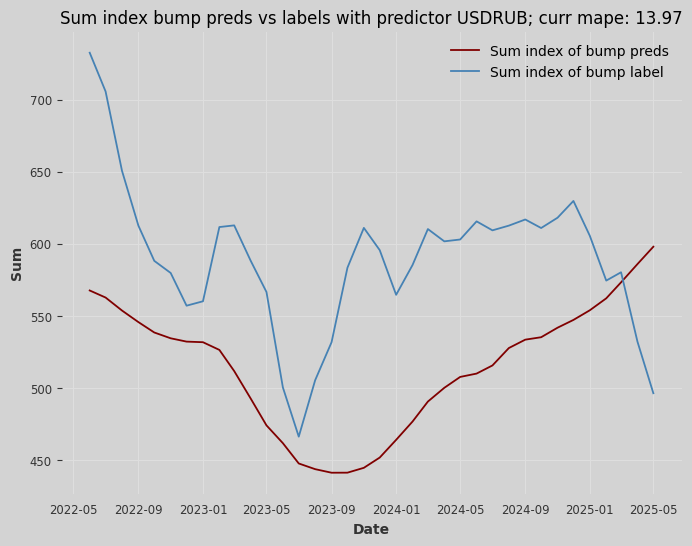

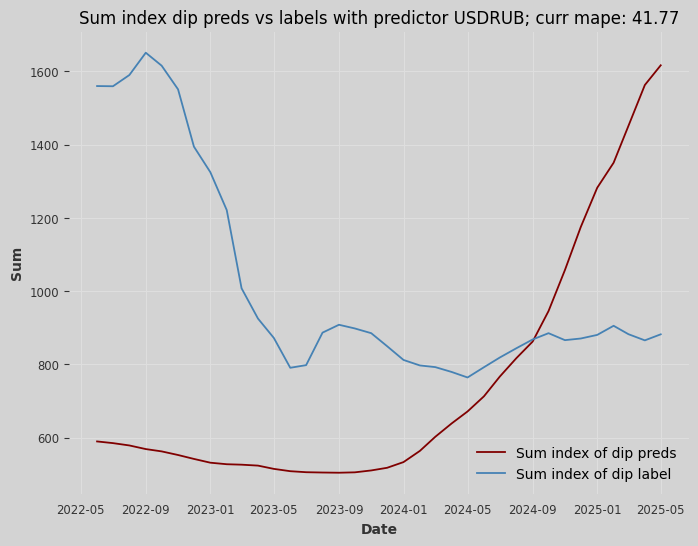

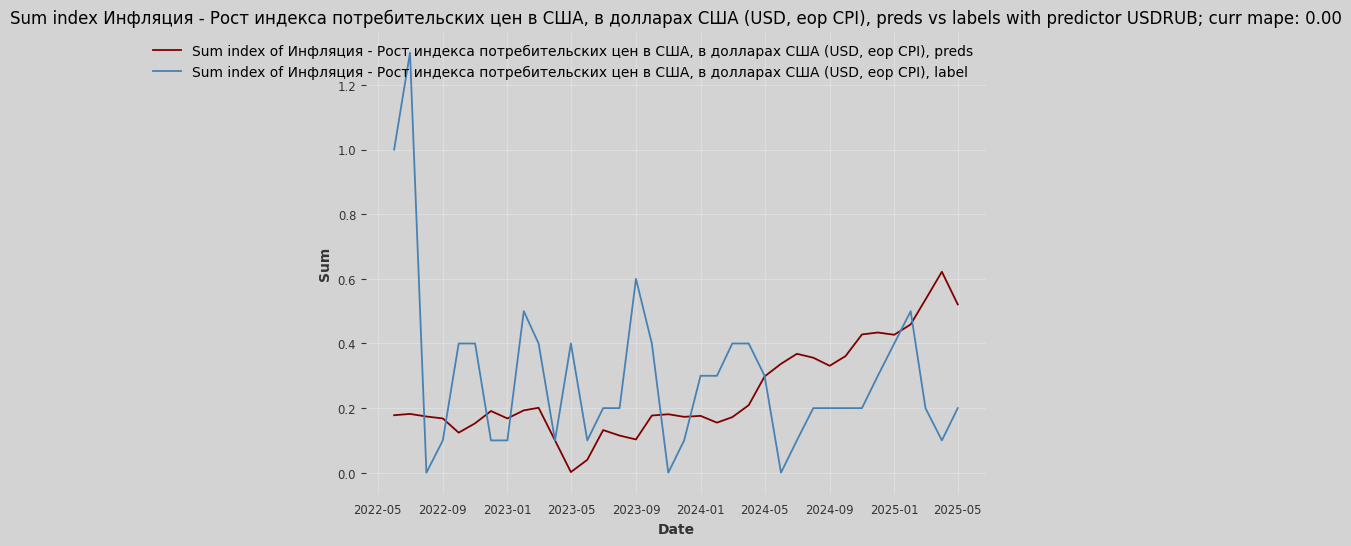

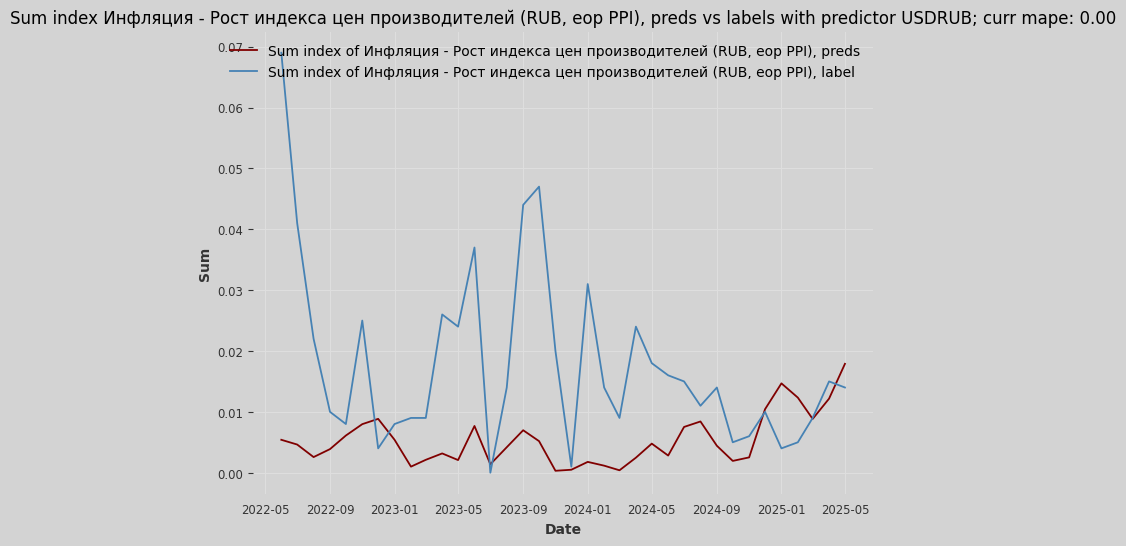

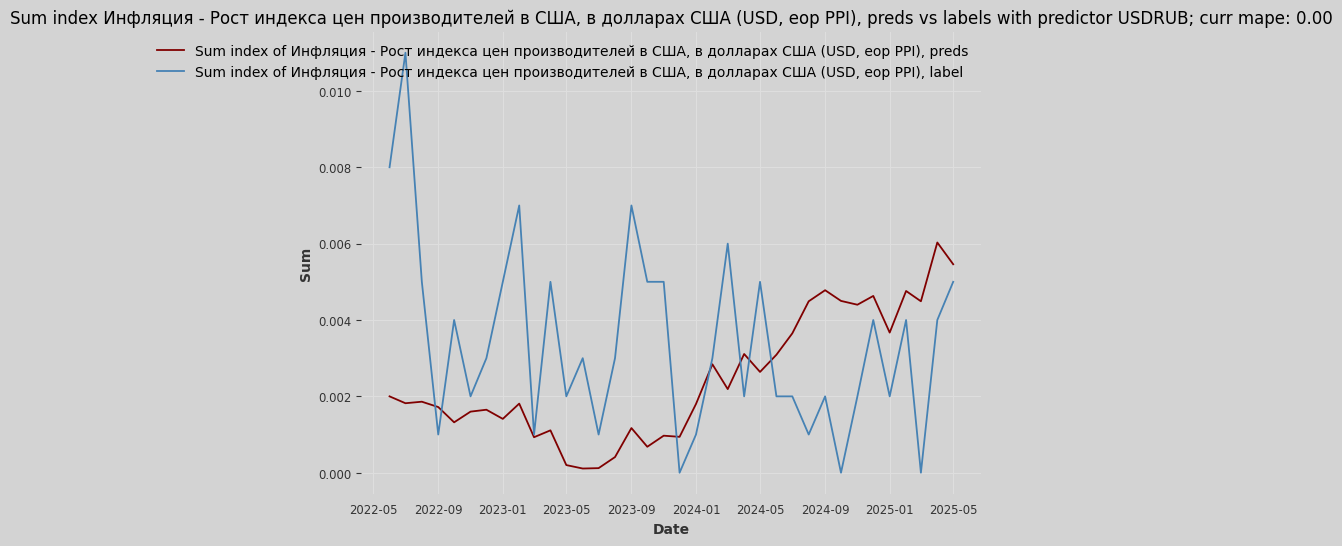

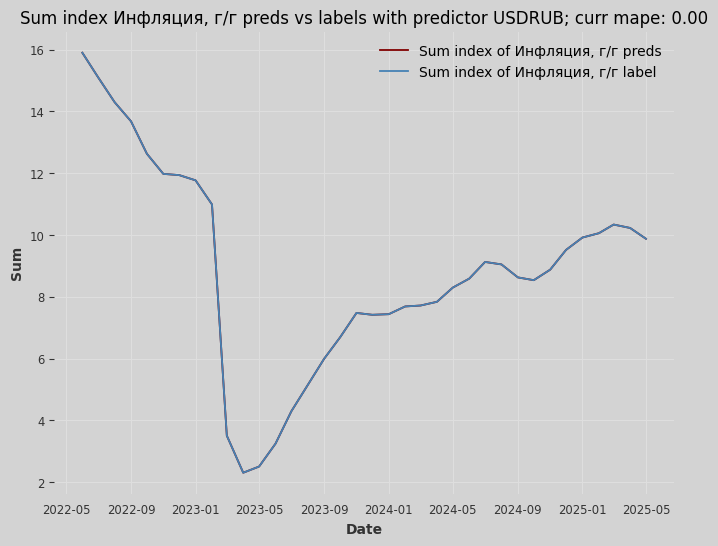

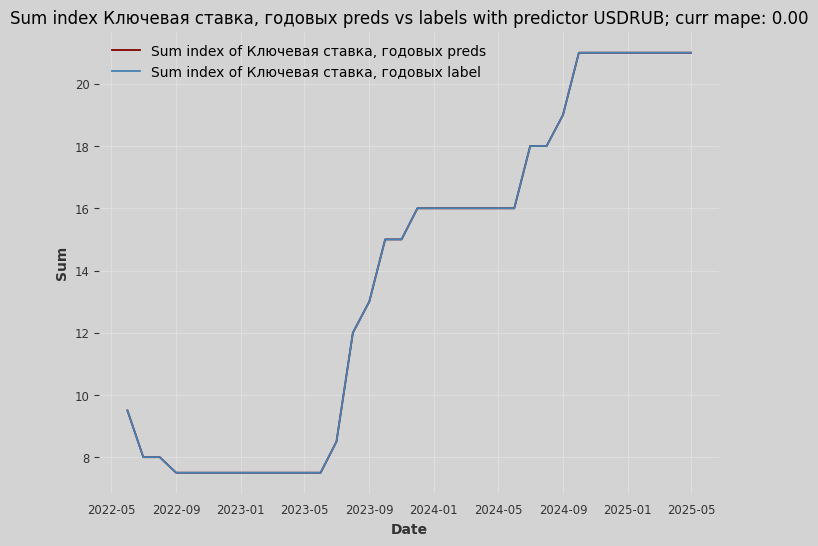

In [5]:
models = train_model_and_eval_res(df_updated,
                         macro_updated,
                         past_idx = past_idx,
                         future_idx = future_idx,
                         predict_up_to=SINGLE_DATAPOINT_TO_PRED,
                         category_map = CATEGORY_MAP,
                         best_predictors_for_idx = BEST_PREDICTORS_FOR_INDEX,
                         target_col_suffix = TARGET_COL_SUFFIX,
                         future_forecaster_ts_name = FUTURE_FORECASTER_TS_NAME,
                         future_forecaster_ts_values = FUTURE_FORECASTER_TS_VALUES,
                         model_name = MODEL_NAME_FOR_FORECASTER,
                         use_future_macro = USE_FUTURE_COV,
                         prediction_horizon = PREDICTION_HORIZON,
                         dir_to_save_plots = f"darts_result_pairs_{MODEL_NAME_FOR_FORECASTER}",
                         dir_to_save_tables = f"darts_result_tables_pairs_{MODEL_NAME_FOR_FORECASTER}",
                         persist_model=PERSIST_MODEL,
                         refit=REFIT_MODEL,
                         prediction_lag=PREDICTOR_LAG,
                         is_backtest=IS_BACKTEST,
                         ts_freq=TS_FREQUENCY,
                         pred_index=new_dates if IS_BACKTEST else None
)
# TODO: Научинтся конвертить в TimeSeries

---
## Inference model

In [4]:
TARGET_COL_SUFFIX = "_norm_sum"

In [5]:
models = load_models(MODEL_NAME_FOR_FORECASTER, MODEL_SAVE_PATH)

[OK] Loaded forecaster ← randomforest_dataset/randomforest_for_Fish_36.pkl
[OK] Loaded model      ← randomforest_dataset/randomforest_for_Fish_36_model.pth
[OK] Loaded forecaster ← randomforest_dataset/randomforest_for_Grains & Seeds_36.pkl
[OK] Loaded model      ← randomforest_dataset/randomforest_for_Grains & Seeds_36_model.pth
[OK] Loaded forecaster ← randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),_36.pkl
[OK] Loaded model      ← randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),_36_model.pth
[OK] Loaded forecaster ← randomforest_dataset/randomforest_for_Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),_36.pkl
[OK] Loaded model      ← randomforest_dataset/randomforest_for_Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),_36_model.pth
[OK] Loaded forecaster ← randomforest_dataset/ra

    Grains & Seeds_norm_sum
0               1323.808063
1               1304.307288
2               1295.834497
3               1282.038029
4               1265.186781
5               1256.499578
6               1264.298514
7               1271.873059
8               1294.859855
9               1321.997622
10              1363.475999
11              1412.066649
12              1461.985284
13              1485.121418
14              1508.403914
15              1521.586078
16              1555.930692
17              1601.337947
18              1639.650759
19              1678.076442
20              1734.432880
21              1788.474899
22              1835.339141
23              1877.623211
24              1882.656486
25              1862.609023
26              1871.574952
27              1862.888723
28              1874.300957
29              1890.892360
30              1905.434986
31              1936.631330
32              1981.342082
33              2042.249827
34              2090

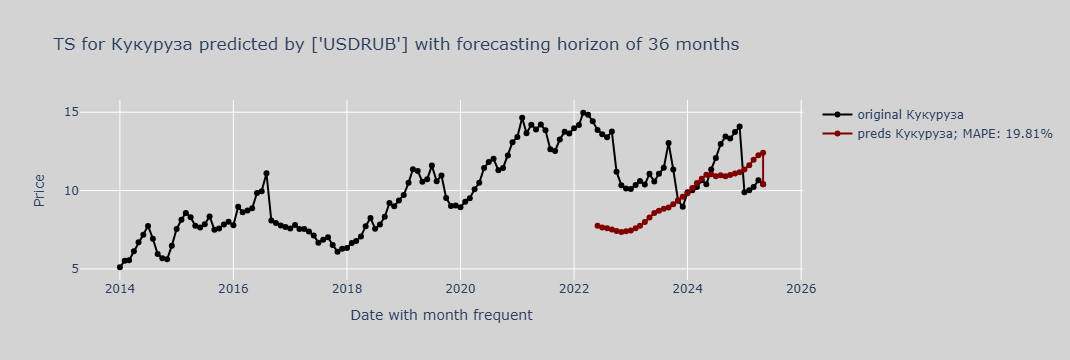

    Grains & Seeds_norm_sum
0               1323.808063
1               1304.307288
2               1295.834497
3               1282.038029
4               1265.186781
5               1256.499578
6               1264.298514
7               1271.873059
8               1294.859855
9               1321.997622
10              1363.475999
11              1412.066649
12              1461.985284
13              1485.121418
14              1508.403914
15              1521.586078
16              1555.930692
17              1601.337947
18              1639.650759
19              1678.076442
20              1734.432880
21              1788.474899
22              1835.339141
23              1877.623211
24              1882.656486
25              1862.609023
26              1871.574952
27              1862.888723
28              1874.300957
29              1890.892360
30              1905.434986
31              1936.631330
32              1981.342082
33              2042.249827
34              2090

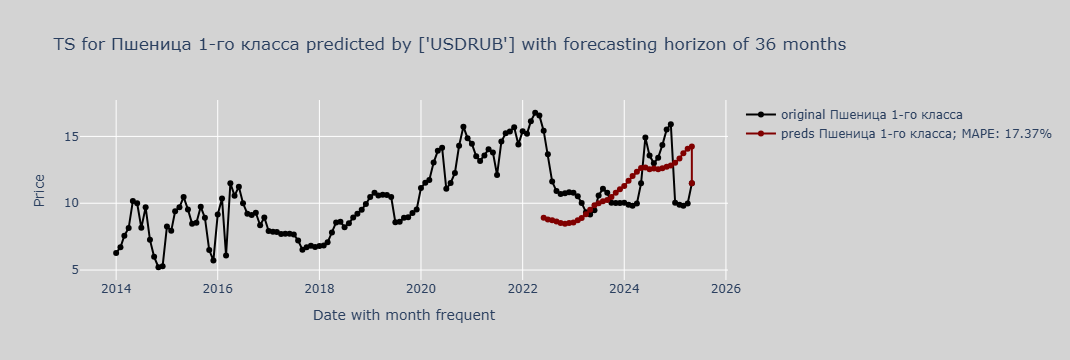

    Grains & Seeds_norm_sum
0               1323.808063
1               1304.307288
2               1295.834497
3               1282.038029
4               1265.186781
5               1256.499578
6               1264.298514
7               1271.873059
8               1294.859855
9               1321.997622
10              1363.475999
11              1412.066649
12              1461.985284
13              1485.121418
14              1508.403914
15              1521.586078
16              1555.930692
17              1601.337947
18              1639.650759
19              1678.076442
20              1734.432880
21              1788.474899
22              1835.339141
23              1877.623211
24              1882.656486
25              1862.609023
26              1871.574952
27              1862.888723
28              1874.300957
29              1890.892360
30              1905.434986
31              1936.631330
32              1981.342082
33              2042.249827
34              2090

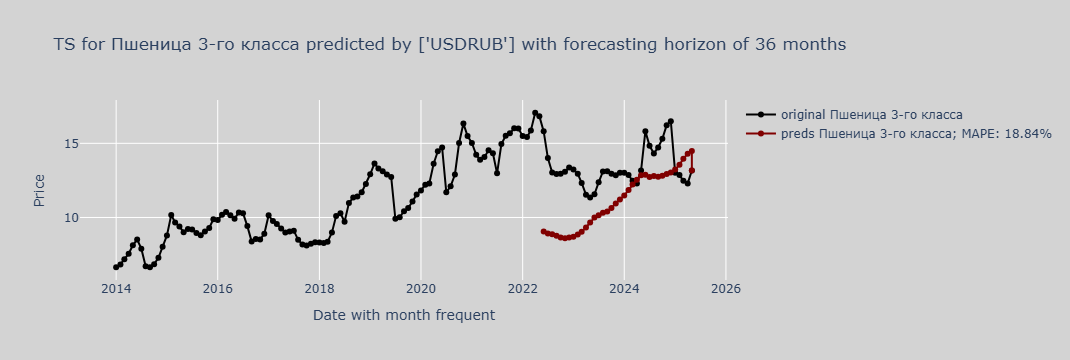

    Grains & Seeds_norm_sum
0               1323.808063
1               1304.307288
2               1295.834497
3               1282.038029
4               1265.186781
5               1256.499578
6               1264.298514
7               1271.873059
8               1294.859855
9               1321.997622
10              1363.475999
11              1412.066649
12              1461.985284
13              1485.121418
14              1508.403914
15              1521.586078
16              1555.930692
17              1601.337947
18              1639.650759
19              1678.076442
20              1734.432880
21              1788.474899
22              1835.339141
23              1877.623211
24              1882.656486
25              1862.609023
26              1871.574952
27              1862.888723
28              1874.300957
29              1890.892360
30              1905.434986
31              1936.631330
32              1981.342082
33              2042.249827
34              2090

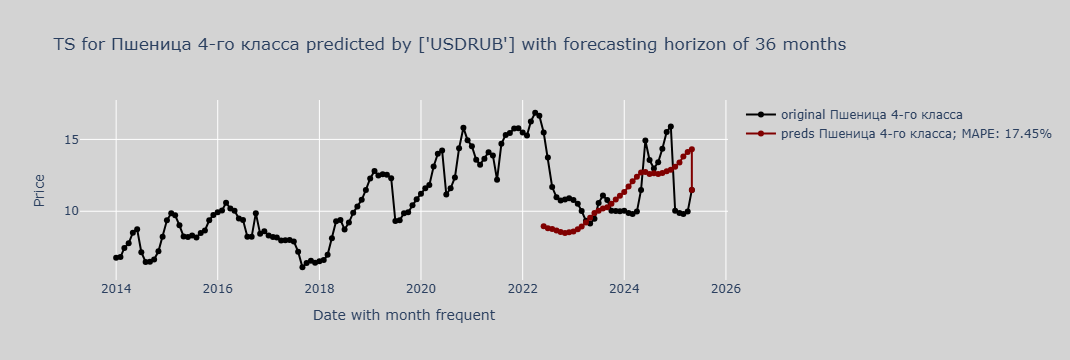

    Grains & Seeds_norm_sum
0               1323.808063
1               1304.307288
2               1295.834497
3               1282.038029
4               1265.186781
5               1256.499578
6               1264.298514
7               1271.873059
8               1294.859855
9               1321.997622
10              1363.475999
11              1412.066649
12              1461.985284
13              1485.121418
14              1508.403914
15              1521.586078
16              1555.930692
17              1601.337947
18              1639.650759
19              1678.076442
20              1734.432880
21              1788.474899
22              1835.339141
23              1877.623211
24              1882.656486
25              1862.609023
26              1871.574952
27              1862.888723
28              1874.300957
29              1890.892360
30              1905.434986
31              1936.631330
32              1981.342082
33              2042.249827
34              2090

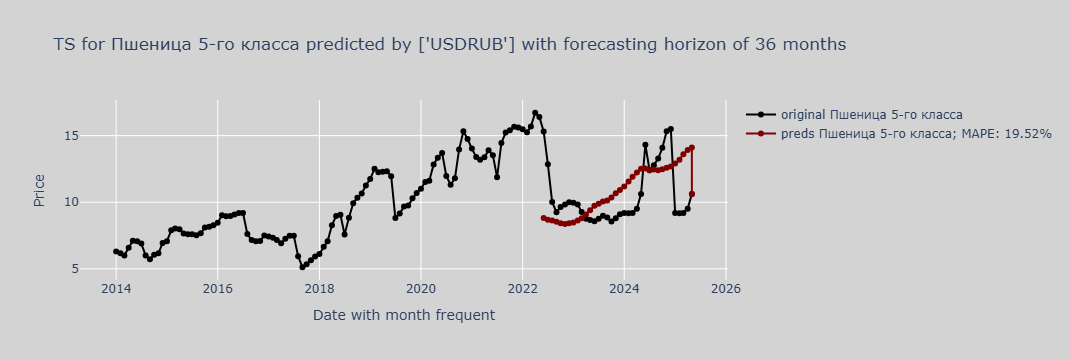

    Grains & Seeds_norm_sum
0               1323.808063
1               1304.307288
2               1295.834497
3               1282.038029
4               1265.186781
5               1256.499578
6               1264.298514
7               1271.873059
8               1294.859855
9               1321.997622
10              1363.475999
11              1412.066649
12              1461.985284
13              1485.121418
14              1508.403914
15              1521.586078
16              1555.930692
17              1601.337947
18              1639.650759
19              1678.076442
20              1734.432880
21              1788.474899
22              1835.339141
23              1877.623211
24              1882.656486
25              1862.609023
26              1871.574952
27              1862.888723
28              1874.300957
29              1890.892360
30              1905.434986
31              1936.631330
32              1981.342082
33              2042.249827
34              2090

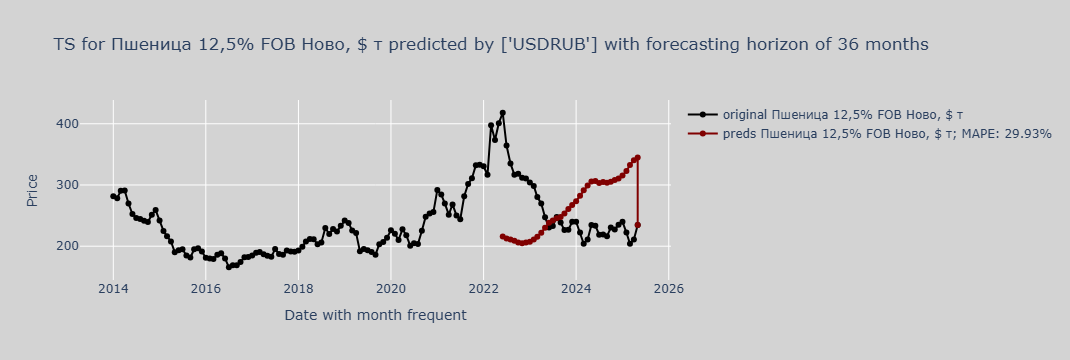

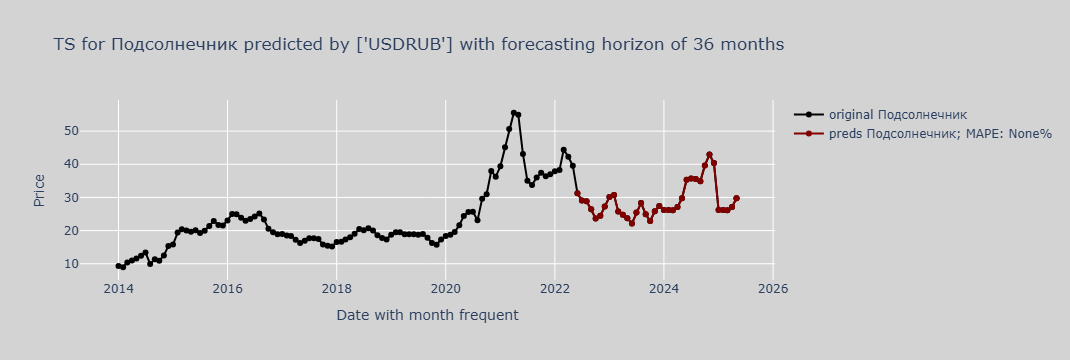

    Grains & Seeds_norm_sum
0               1323.808063
1               1304.307288
2               1295.834497
3               1282.038029
4               1265.186781
5               1256.499578
6               1264.298514
7               1271.873059
8               1294.859855
9               1321.997622
10              1363.475999
11              1412.066649
12              1461.985284
13              1485.121418
14              1508.403914
15              1521.586078
16              1555.930692
17              1601.337947
18              1639.650759
19              1678.076442
20              1734.432880
21              1788.474899
22              1835.339141
23              1877.623211
24              1882.656486
25              1862.609023
26              1871.574952
27              1862.888723
28              1874.300957
29              1890.892360
30              1905.434986
31              1936.631330
32              1981.342082
33              2042.249827
34              2090

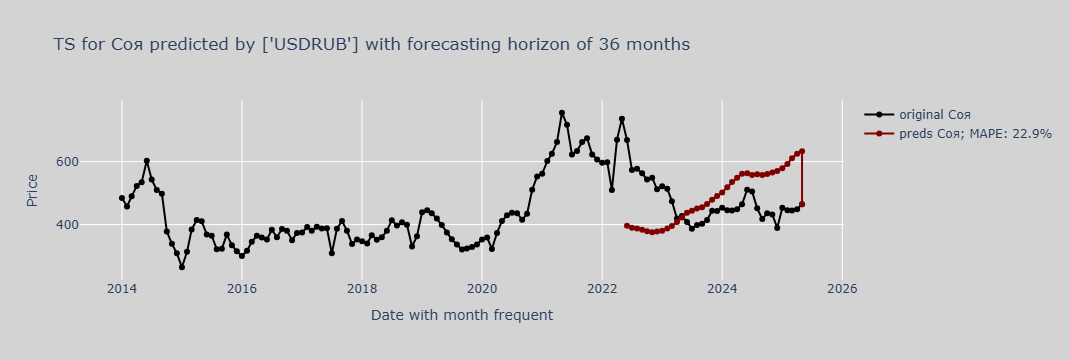

    Grains & Seeds_norm_sum
0               1323.808063
1               1304.307288
2               1295.834497
3               1282.038029
4               1265.186781
5               1256.499578
6               1264.298514
7               1271.873059
8               1294.859855
9               1321.997622
10              1363.475999
11              1412.066649
12              1461.985284
13              1485.121418
14              1508.403914
15              1521.586078
16              1555.930692
17              1601.337947
18              1639.650759
19              1678.076442
20              1734.432880
21              1788.474899
22              1835.339141
23              1877.623211
24              1882.656486
25              1862.609023
26              1871.574952
27              1862.888723
28              1874.300957
29              1890.892360
30              1905.434986
31              1936.631330
32              1981.342082
33              2042.249827
34              2090

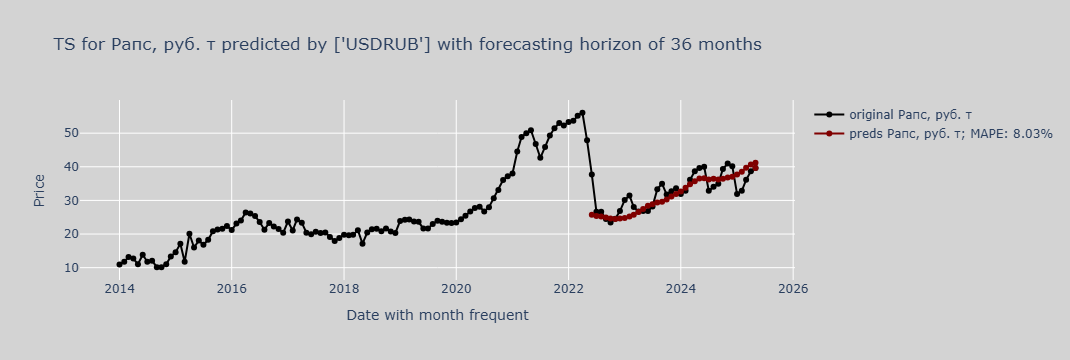

    Oils & Meals_norm_sum
0             1094.223113
1             1086.742164
2             1091.218682
3             1099.196915
4             1097.436785
5             1093.483933
6             1098.378436
7             1113.070134
8             1112.118236
9             1104.340541
10            1112.917052
11            1128.319372
12            1138.234350
13            1151.088862
14            1165.994933
15            1192.224805
16            1222.731903
17            1260.741961
18            1310.710063
19            1347.436814
20            1376.452132
21            1413.145461
22            1460.354082
23            1504.285898
24            1526.002024
25            1511.172470
26            1511.895242
27            1521.171241
28            1543.951514
29            1590.011580
30            1619.588597
31            1643.418067
32            1684.525695
33            1777.218300
34            1911.867888
35            1899.853172


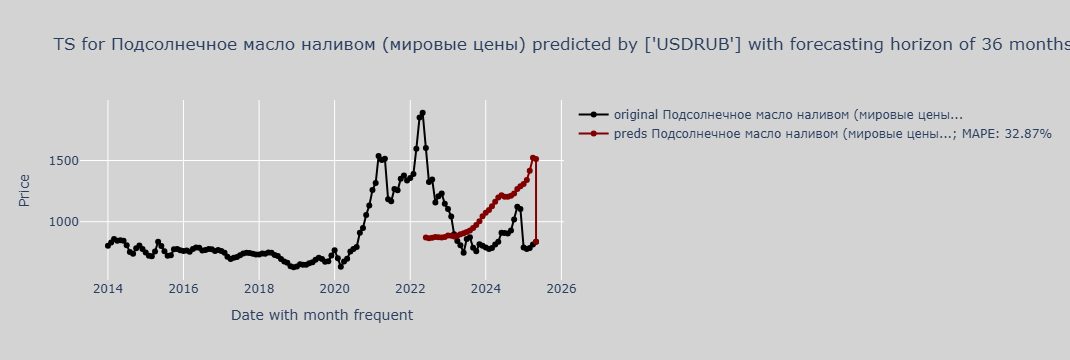

    Oils & Meals_norm_sum
0             1094.223113
1             1086.742164
2             1091.218682
3             1099.196915
4             1097.436785
5             1093.483933
6             1098.378436
7             1113.070134
8             1112.118236
9             1104.340541
10            1112.917052
11            1128.319372
12            1138.234350
13            1151.088862
14            1165.994933
15            1192.224805
16            1222.731903
17            1260.741961
18            1310.710063
19            1347.436814
20            1376.452132
21            1413.145461
22            1460.354082
23            1504.285898
24            1526.002024
25            1511.172470
26            1511.895242
27            1521.171241
28            1543.951514
29            1590.011580
30            1619.588597
31            1643.418067
32            1684.525695
33            1777.218300
34            1911.867888
35            1899.853172


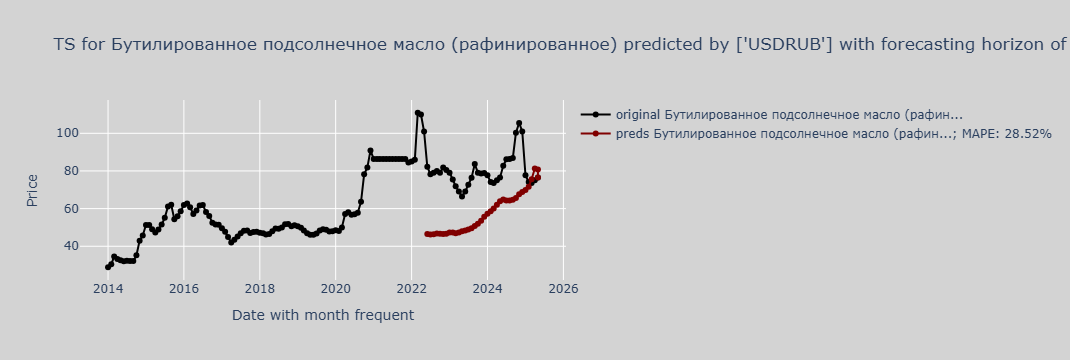

    Oils & Meals_norm_sum
0             1094.223113
1             1086.742164
2             1091.218682
3             1099.196915
4             1097.436785
5             1093.483933
6             1098.378436
7             1113.070134
8             1112.118236
9             1104.340541
10            1112.917052
11            1128.319372
12            1138.234350
13            1151.088862
14            1165.994933
15            1192.224805
16            1222.731903
17            1260.741961
18            1310.710063
19            1347.436814
20            1376.452132
21            1413.145461
22            1460.354082
23            1504.285898
24            1526.002024
25            1511.172470
26            1511.895242
27            1521.171241
28            1543.951514
29            1590.011580
30            1619.588597
31            1643.418067
32            1684.525695
33            1777.218300
34            1911.867888
35            1899.853172


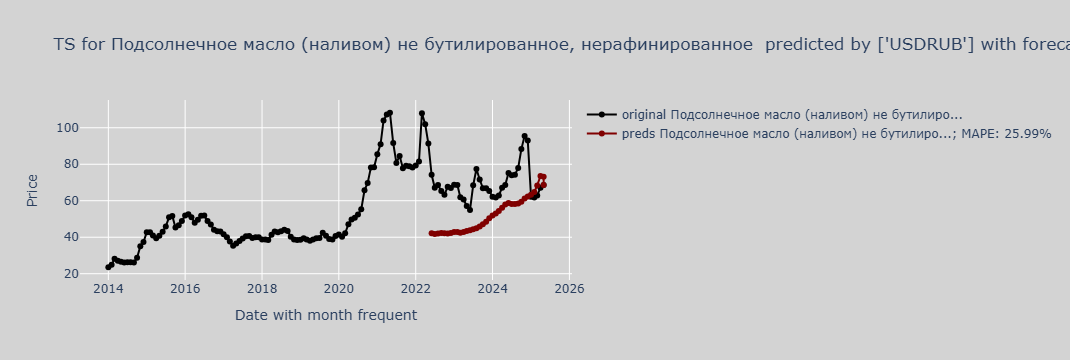

    Oils & Meals_norm_sum
0             1094.223113
1             1086.742164
2             1091.218682
3             1099.196915
4             1097.436785
5             1093.483933
6             1098.378436
7             1113.070134
8             1112.118236
9             1104.340541
10            1112.917052
11            1128.319372
12            1138.234350
13            1151.088862
14            1165.994933
15            1192.224805
16            1222.731903
17            1260.741961
18            1310.710063
19            1347.436814
20            1376.452132
21            1413.145461
22            1460.354082
23            1504.285898
24            1526.002024
25            1511.172470
26            1511.895242
27            1521.171241
28            1543.951514
29            1590.011580
30            1619.588597
31            1643.418067
32            1684.525695
33            1777.218300
34            1911.867888
35            1899.853172


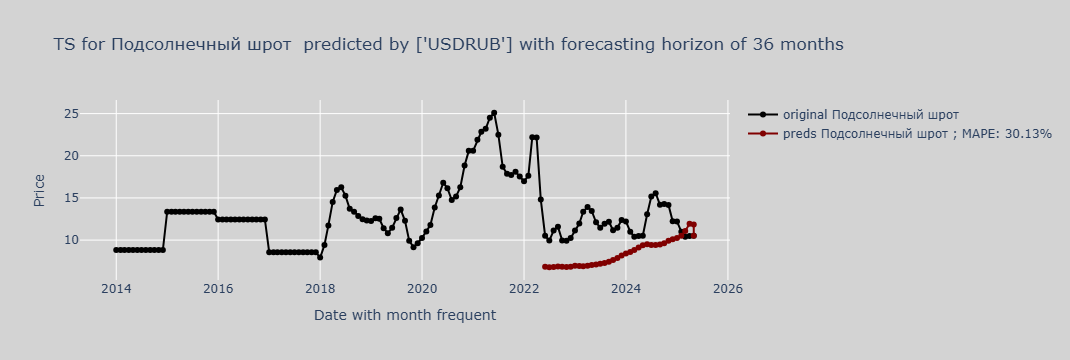

    Oils & Meals_norm_sum
0             1094.223113
1             1086.742164
2             1091.218682
3             1099.196915
4             1097.436785
5             1093.483933
6             1098.378436
7             1113.070134
8             1112.118236
9             1104.340541
10            1112.917052
11            1128.319372
12            1138.234350
13            1151.088862
14            1165.994933
15            1192.224805
16            1222.731903
17            1260.741961
18            1310.710063
19            1347.436814
20            1376.452132
21            1413.145461
22            1460.354082
23            1504.285898
24            1526.002024
25            1511.172470
26            1511.895242
27            1521.171241
28            1543.951514
29            1590.011580
30            1619.588597
31            1643.418067
32            1684.525695
33            1777.218300
34            1911.867888
35            1899.853172


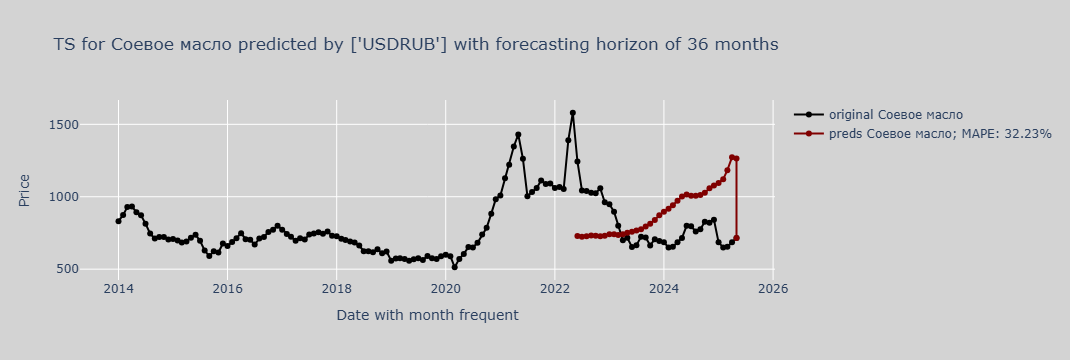

    Oils & Meals_norm_sum
0             1094.223113
1             1086.742164
2             1091.218682
3             1099.196915
4             1097.436785
5             1093.483933
6             1098.378436
7             1113.070134
8             1112.118236
9             1104.340541
10            1112.917052
11            1128.319372
12            1138.234350
13            1151.088862
14            1165.994933
15            1192.224805
16            1222.731903
17            1260.741961
18            1310.710063
19            1347.436814
20            1376.452132
21            1413.145461
22            1460.354082
23            1504.285898
24            1526.002024
25            1511.172470
26            1511.895242
27            1521.171241
28            1543.951514
29            1590.011580
30            1619.588597
31            1643.418067
32            1684.525695
33            1777.218300
34            1911.867888
35            1899.853172


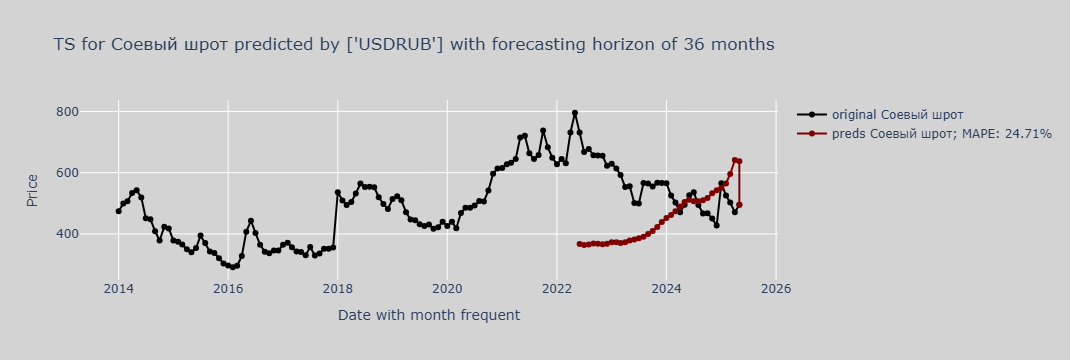

    Oils & Meals_norm_sum
0             1094.223113
1             1086.742164
2             1091.218682
3             1099.196915
4             1097.436785
5             1093.483933
6             1098.378436
7             1113.070134
8             1112.118236
9             1104.340541
10            1112.917052
11            1128.319372
12            1138.234350
13            1151.088862
14            1165.994933
15            1192.224805
16            1222.731903
17            1260.741961
18            1310.710063
19            1347.436814
20            1376.452132
21            1413.145461
22            1460.354082
23            1504.285898
24            1526.002024
25            1511.172470
26            1511.895242
27            1521.171241
28            1543.951514
29            1590.011580
30            1619.588597
31            1643.418067
32            1684.525695
33            1777.218300
34            1911.867888
35            1899.853172


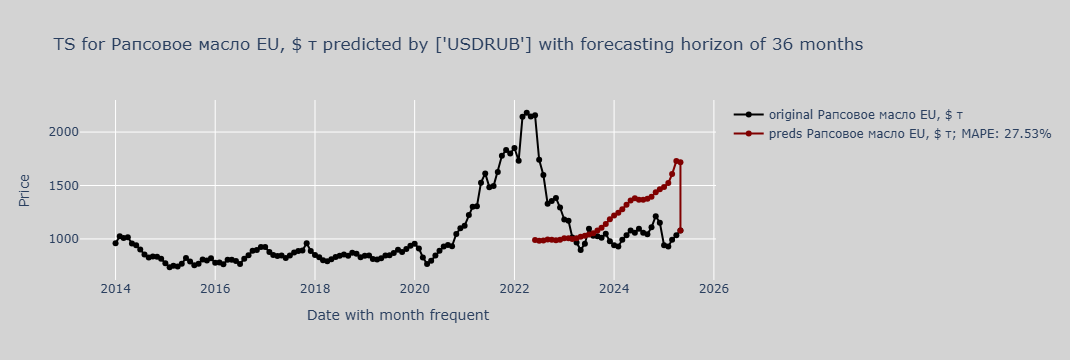

    Oils & Meals_norm_sum
0             1094.223113
1             1086.742164
2             1091.218682
3             1099.196915
4             1097.436785
5             1093.483933
6             1098.378436
7             1113.070134
8             1112.118236
9             1104.340541
10            1112.917052
11            1128.319372
12            1138.234350
13            1151.088862
14            1165.994933
15            1192.224805
16            1222.731903
17            1260.741961
18            1310.710063
19            1347.436814
20            1376.452132
21            1413.145461
22            1460.354082
23            1504.285898
24            1526.002024
25            1511.172470
26            1511.895242
27            1521.171241
28            1543.951514
29            1590.011580
30            1619.588597
31            1643.418067
32            1684.525695
33            1777.218300
34            1911.867888
35            1899.853172


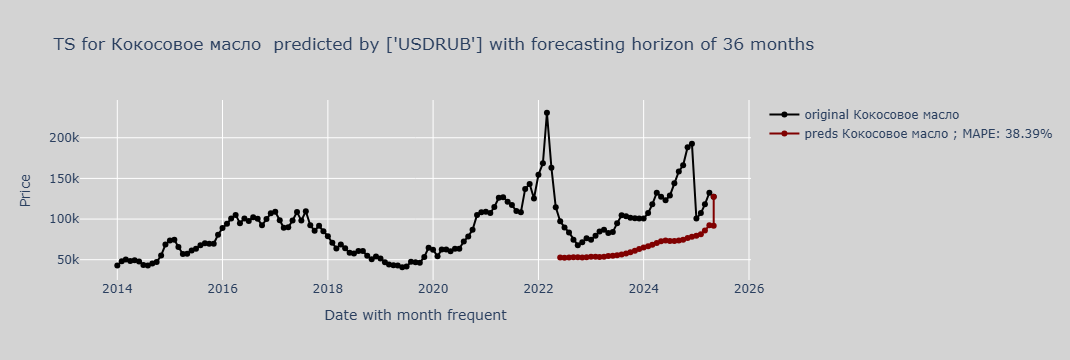

    Oils & Meals_norm_sum
0             1094.223113
1             1086.742164
2             1091.218682
3             1099.196915
4             1097.436785
5             1093.483933
6             1098.378436
7             1113.070134
8             1112.118236
9             1104.340541
10            1112.917052
11            1128.319372
12            1138.234350
13            1151.088862
14            1165.994933
15            1192.224805
16            1222.731903
17            1260.741961
18            1310.710063
19            1347.436814
20            1376.452132
21            1413.145461
22            1460.354082
23            1504.285898
24            1526.002024
25            1511.172470
26            1511.895242
27            1521.171241
28            1543.951514
29            1590.011580
30            1619.588597
31            1643.418067
32            1684.525695
33            1777.218300
34            1911.867888
35            1899.853172


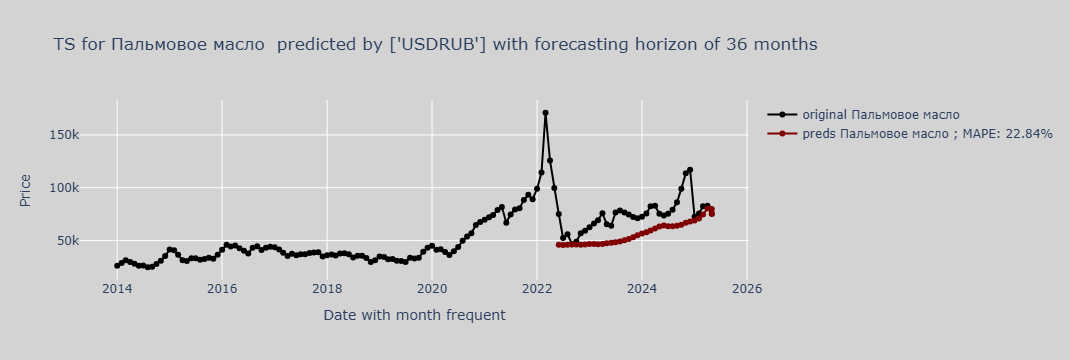

    Livestock & Meat_norm_sum
0                  881.148536
1                  881.137948
2                  881.682340
3                  882.618974
4                  886.604308
5                  890.552453
6                  895.848315
7                  908.400889
8                  919.241765
9                  911.712813
10                 899.095522
11                 899.748639
12                 902.740827
13                 910.884250
14                 925.561400
15                 925.892069
16                 920.097833
17                 924.230958
18                 936.617977
19                 944.522338
20                 946.756247
21                 960.837102
22                 979.301779
23                 985.504648
24                 985.622490
25                 985.830914
26                 987.278724
27                 997.940818
28                1007.809356
29                1015.443251
30                1037.744241
31                1035.968316
32        

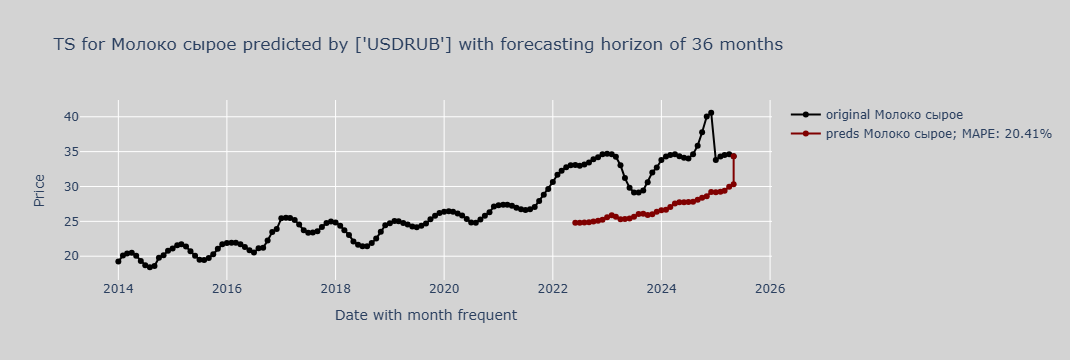

    Livestock & Meat_norm_sum
0                  881.148536
1                  881.137948
2                  881.682340
3                  882.618974
4                  886.604308
5                  890.552453
6                  895.848315
7                  908.400889
8                  919.241765
9                  911.712813
10                 899.095522
11                 899.748639
12                 902.740827
13                 910.884250
14                 925.561400
15                 925.892069
16                 920.097833
17                 924.230958
18                 936.617977
19                 944.522338
20                 946.756247
21                 960.837102
22                 979.301779
23                 985.504648
24                 985.622490
25                 985.830914
26                 987.278724
27                 997.940818
28                1007.809356
29                1015.443251
30                1037.744241
31                1035.968316
32        

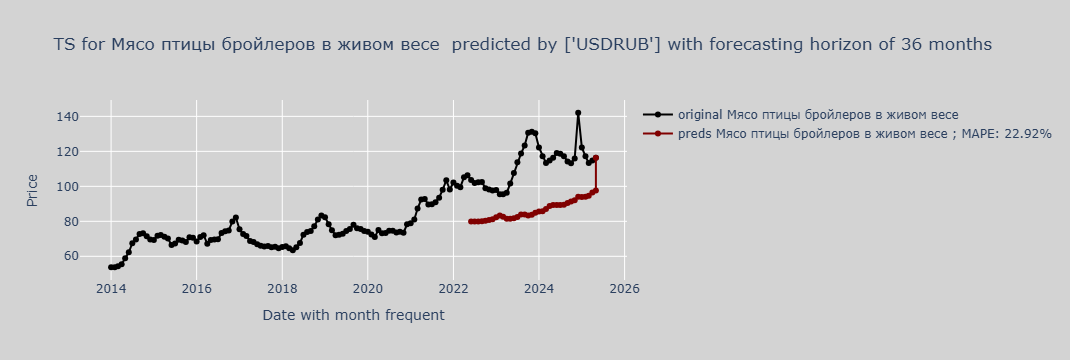

    Livestock & Meat_norm_sum
0                  881.148536
1                  881.137948
2                  881.682340
3                  882.618974
4                  886.604308
5                  890.552453
6                  895.848315
7                  908.400889
8                  919.241765
9                  911.712813
10                 899.095522
11                 899.748639
12                 902.740827
13                 910.884250
14                 925.561400
15                 925.892069
16                 920.097833
17                 924.230958
18                 936.617977
19                 944.522338
20                 946.756247
21                 960.837102
22                 979.301779
23                 985.504648
24                 985.622490
25                 985.830914
26                 987.278724
27                 997.940818
28                1007.809356
29                1015.443251
30                1037.744241
31                1035.968316
32        

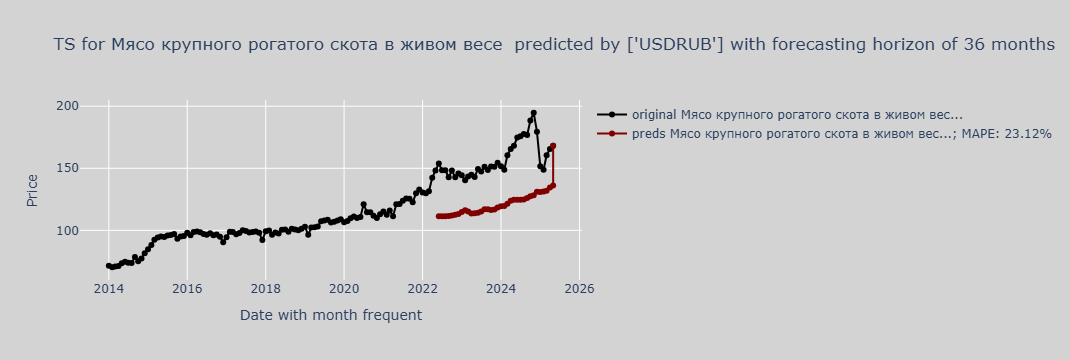

    Livestock & Meat_norm_sum
0                  881.148536
1                  881.137948
2                  881.682340
3                  882.618974
4                  886.604308
5                  890.552453
6                  895.848315
7                  908.400889
8                  919.241765
9                  911.712813
10                 899.095522
11                 899.748639
12                 902.740827
13                 910.884250
14                 925.561400
15                 925.892069
16                 920.097833
17                 924.230958
18                 936.617977
19                 944.522338
20                 946.756247
21                 960.837102
22                 979.301779
23                 985.504648
24                 985.622490
25                 985.830914
26                 987.278724
27                 997.940818
28                1007.809356
29                1015.443251
30                1037.744241
31                1035.968316
32        

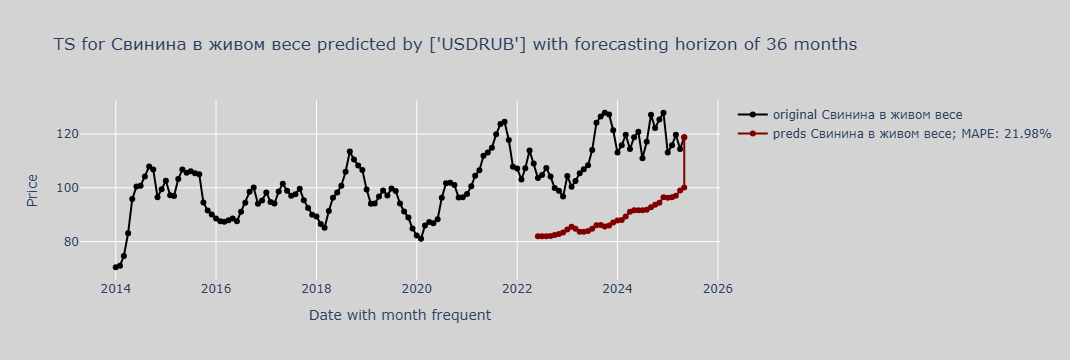

    Livestock & Meat_norm_sum
0                  881.148536
1                  881.137948
2                  881.682340
3                  882.618974
4                  886.604308
5                  890.552453
6                  895.848315
7                  908.400889
8                  919.241765
9                  911.712813
10                 899.095522
11                 899.748639
12                 902.740827
13                 910.884250
14                 925.561400
15                 925.892069
16                 920.097833
17                 924.230958
18                 936.617977
19                 944.522338
20                 946.756247
21                 960.837102
22                 979.301779
23                 985.504648
24                 985.622490
25                 985.830914
26                 987.278724
27                 997.940818
28                1007.809356
29                1015.443251
30                1037.744241
31                1035.968316
32        

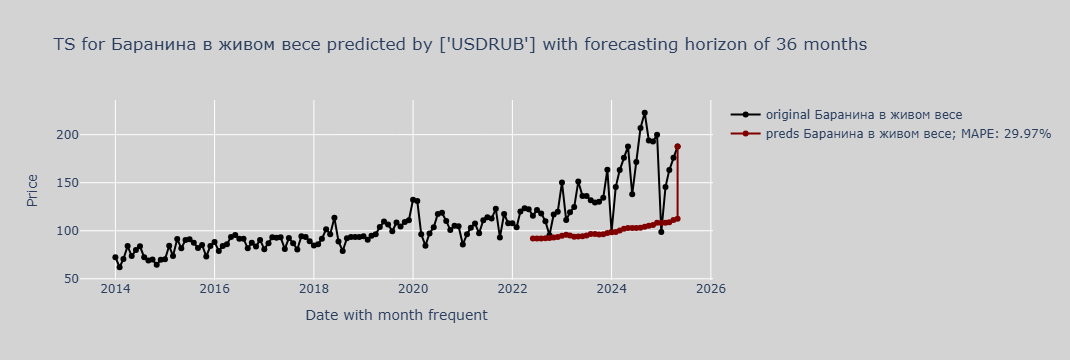

    Livestock & Meat_norm_sum
0                  881.148536
1                  881.137948
2                  881.682340
3                  882.618974
4                  886.604308
5                  890.552453
6                  895.848315
7                  908.400889
8                  919.241765
9                  911.712813
10                 899.095522
11                 899.748639
12                 902.740827
13                 910.884250
14                 925.561400
15                 925.892069
16                 920.097833
17                 924.230958
18                 936.617977
19                 944.522338
20                 946.756247
21                 960.837102
22                 979.301779
23                 985.504648
24                 985.622490
25                 985.830914
26                 987.278724
27                 997.940818
28                1007.809356
29                1015.443251
30                1037.744241
31                1035.968316
32        

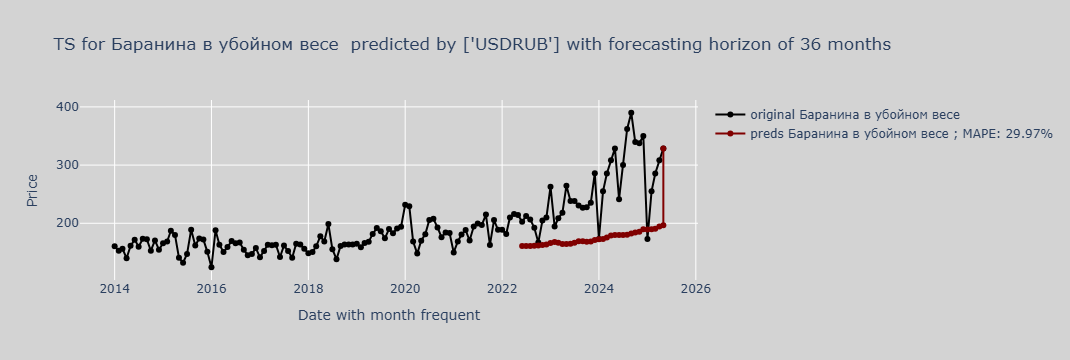

    Livestock & Meat_norm_sum
0                  881.148536
1                  881.137948
2                  881.682340
3                  882.618974
4                  886.604308
5                  890.552453
6                  895.848315
7                  908.400889
8                  919.241765
9                  911.712813
10                 899.095522
11                 899.748639
12                 902.740827
13                 910.884250
14                 925.561400
15                 925.892069
16                 920.097833
17                 924.230958
18                 936.617977
19                 944.522338
20                 946.756247
21                 960.837102
22                 979.301779
23                 985.504648
24                 985.622490
25                 985.830914
26                 987.278724
27                 997.940818
28                1007.809356
29                1015.443251
30                1037.744241
31                1035.968316
32        

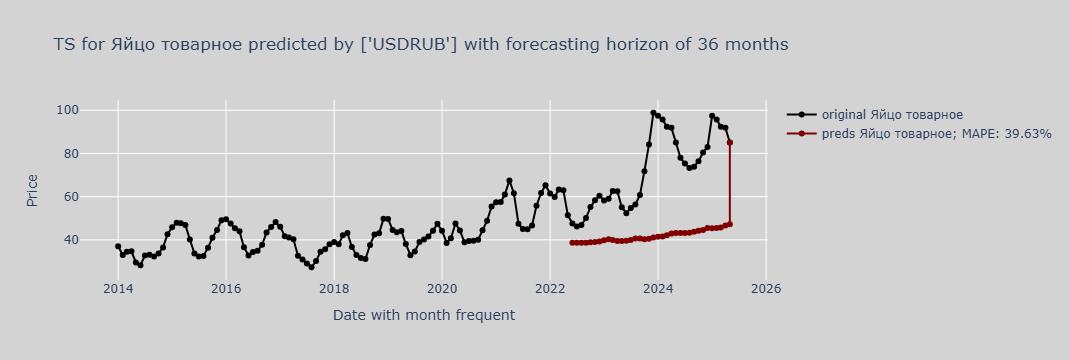

    Processed Meat_norm_sum
0                226.616450
1                225.835241
2                225.897361
3                227.062991
4                227.558400
5                227.683476
6                228.750111
7                229.579931
8                231.442404
9                232.576853
10               232.229880
11               232.268297
12               232.789451
13               232.371985
14               232.974292
15               233.139163
16               234.331326
17               234.516046
18               235.764320
19               237.516935
20               239.240995
21               240.917734
22               243.039223
23               244.876814
24               245.869358
25               246.031418
26               246.105081
27               246.495519
28               247.119489
29               248.917704
30               250.398054
31               253.089598
32               254.089755
33               257.014500
34               261

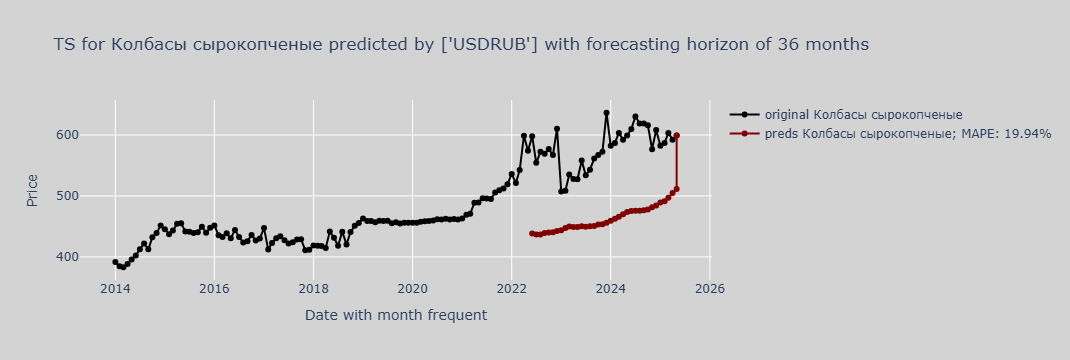

    Processed Meat_norm_sum
0                226.616450
1                225.835241
2                225.897361
3                227.062991
4                227.558400
5                227.683476
6                228.750111
7                229.579931
8                231.442404
9                232.576853
10               232.229880
11               232.268297
12               232.789451
13               232.371985
14               232.974292
15               233.139163
16               234.331326
17               234.516046
18               235.764320
19               237.516935
20               239.240995
21               240.917734
22               243.039223
23               244.876814
24               245.869358
25               246.031418
26               246.105081
27               246.495519
28               247.119489
29               248.917704
30               250.398054
31               253.089598
32               254.089755
33               257.014500
34               261

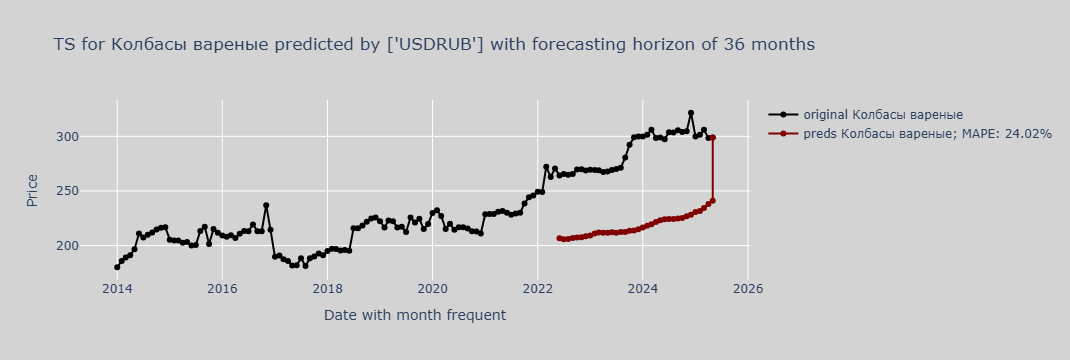

    Fish_norm_sum
0      424.000964
1      428.439591
2      426.497258
3      426.722789
4      434.304661
5      437.412441
6      438.404984
7      437.156915
8      435.326867
9      431.826270
10     423.234326
11     416.730032
12     409.134812
13     405.320750
14     403.255068
15     401.414559
16     403.175104
17     415.181241
18     423.105944
19     431.817174
20     439.739517
21     449.447086
22     463.467630
23     469.171598
24     476.162039
25     477.968988
26     473.677999
27     470.666784
28     472.739297
29     480.027344
30     488.920965
31     496.888879
32     504.091092
33     512.066189
34     519.106093
35     519.648503


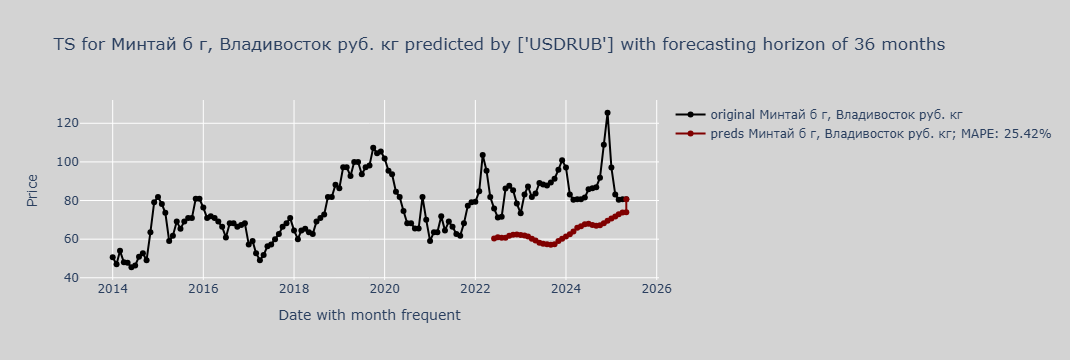

    Fish_norm_sum
0      424.000964
1      428.439591
2      426.497258
3      426.722789
4      434.304661
5      437.412441
6      438.404984
7      437.156915
8      435.326867
9      431.826270
10     423.234326
11     416.730032
12     409.134812
13     405.320750
14     403.255068
15     401.414559
16     403.175104
17     415.181241
18     423.105944
19     431.817174
20     439.739517
21     449.447086
22     463.467630
23     469.171598
24     476.162039
25     477.968988
26     473.677999
27     470.666784
28     472.739297
29     480.027344
30     488.920965
31     496.888879
32     504.091092
33     512.066189
34     519.106093
35     519.648503


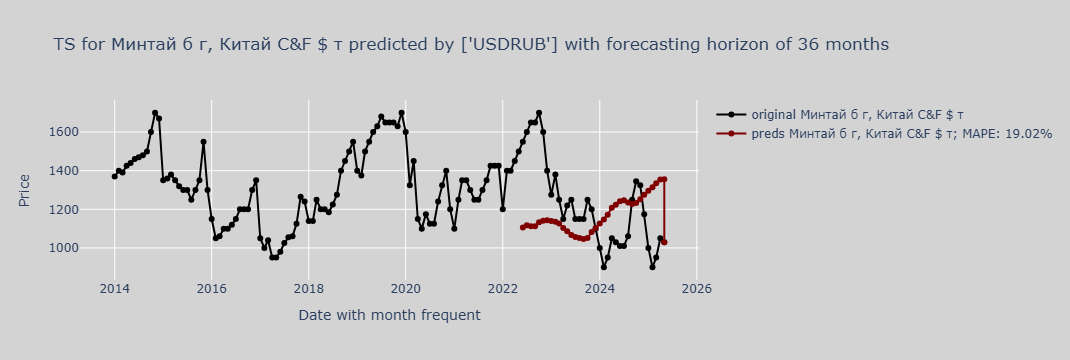

    Fish_norm_sum
0      424.000964
1      428.439591
2      426.497258
3      426.722789
4      434.304661
5      437.412441
6      438.404984
7      437.156915
8      435.326867
9      431.826270
10     423.234326
11     416.730032
12     409.134812
13     405.320750
14     403.255068
15     401.414559
16     403.175104
17     415.181241
18     423.105944
19     431.817174
20     439.739517
21     449.447086
22     463.467630
23     469.171598
24     476.162039
25     477.968988
26     473.677999
27     470.666784
28     472.739297
29     480.027344
30     488.920965
31     496.888879
32     504.091092
33     512.066189
34     519.106093
35     519.648503


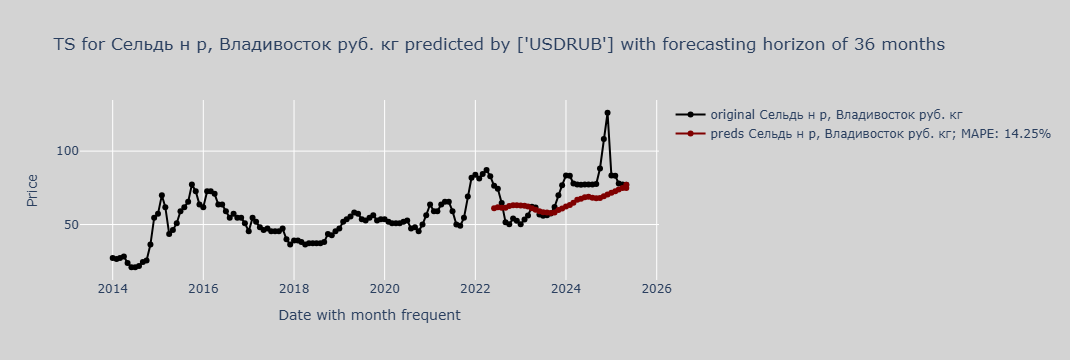

    Vegetables_norm_sum
0            141.878834
1            123.638202
2            114.180984
3            118.323038
4            142.379417
5            169.636144
6            209.153037
7            229.956371
8            245.438880
9            234.040008
10           204.889613
11           174.926106
12           147.824960
13           124.249706
14           112.400700
15           117.891614
16           135.408902
17           165.612678
18           204.190129
19           235.904014
20           251.876979
21           234.380022
22           211.727126
23           183.334148
24           152.710787
25           129.857974
26           118.515466
27           126.603104
28           159.474405
29           184.052212
30           217.650928
31           243.103210
32           253.876100
33           245.751223
34           225.457406
35           195.856667


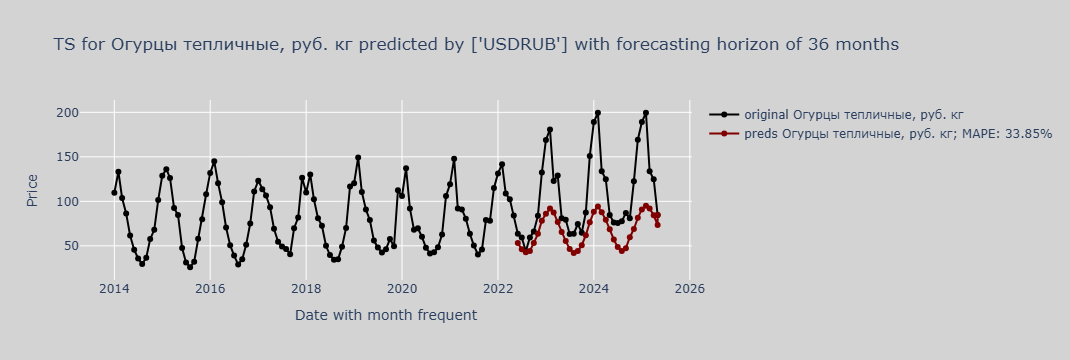

    Vegetables_norm_sum
0            141.878834
1            123.638202
2            114.180984
3            118.323038
4            142.379417
5            169.636144
6            209.153037
7            229.956371
8            245.438880
9            234.040008
10           204.889613
11           174.926106
12           147.824960
13           124.249706
14           112.400700
15           117.891614
16           135.408902
17           165.612678
18           204.190129
19           235.904014
20           251.876979
21           234.380022
22           211.727126
23           183.334148
24           152.710787
25           129.857974
26           118.515466
27           126.603104
28           159.474405
29           184.052212
30           217.650928
31           243.103210
32           253.876100
33           245.751223
34           225.457406
35           195.856667


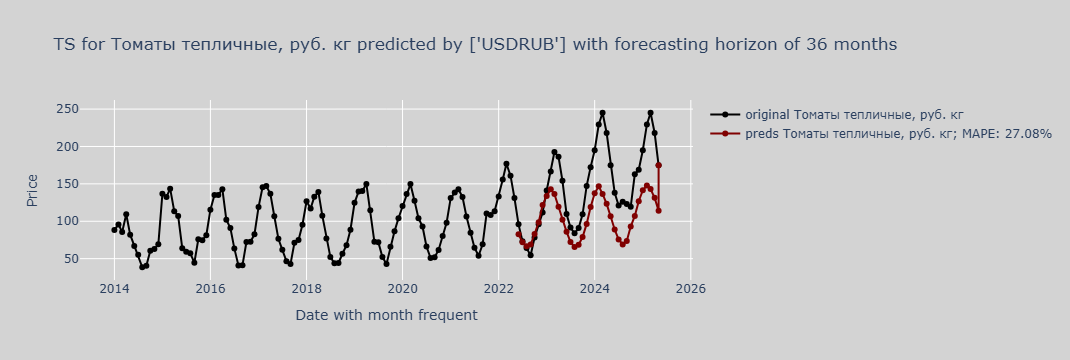

    Sugar & Flour_norm_sum
0               274.887344
1               271.534282
2               266.989038
3               261.992332
4               255.212177
5               249.347048
6               244.146689
7               239.279887
8               238.846908
9               242.687874
10              249.120047
11              255.528149
12              262.158063
13              269.406206
14              275.267257
15              283.049705
16              293.107528
17              301.869766
18              307.696812
19              312.315357
20              318.160771
21              322.362991
22              324.374806
23              324.941530
24              324.256386
25              321.822325
26              319.189627
27              320.348616
28              321.951301
29              324.785570
30              329.452748
31              334.446228
32              339.253580
33              353.893632
34              370.537097
35              382.554957


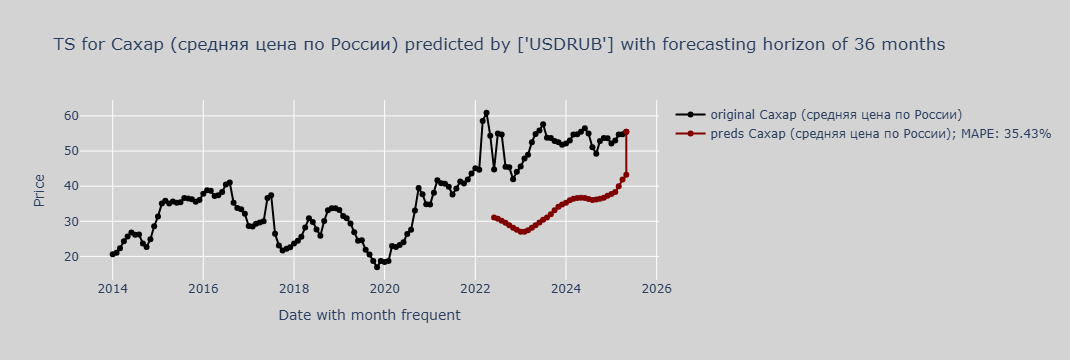

    Sugar & Flour_norm_sum
0               274.887344
1               271.534282
2               266.989038
3               261.992332
4               255.212177
5               249.347048
6               244.146689
7               239.279887
8               238.846908
9               242.687874
10              249.120047
11              255.528149
12              262.158063
13              269.406206
14              275.267257
15              283.049705
16              293.107528
17              301.869766
18              307.696812
19              312.315357
20              318.160771
21              322.362991
22              324.374806
23              324.941530
24              324.256386
25              321.822325
26              319.189627
27              320.348616
28              321.951301
29              324.785570
30              329.452748
31              334.446228
32              339.253580
33              353.893632
34              370.537097
35              382.554957


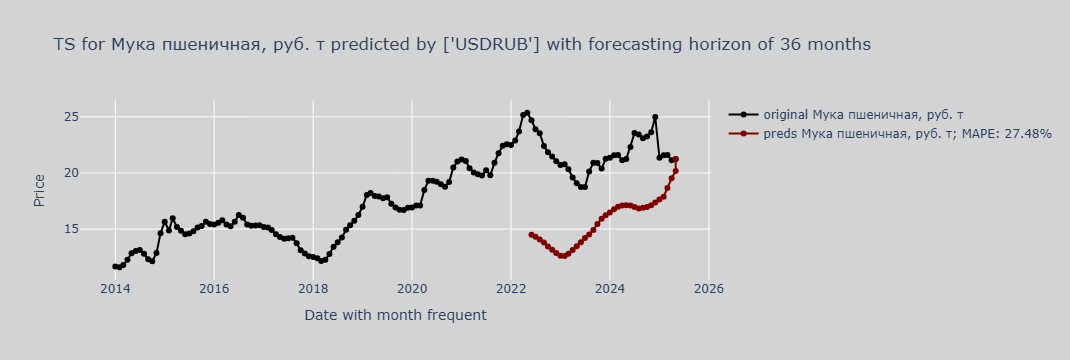

    Stimuli Crops_norm_sum
0               308.061621
1               305.990018
2               304.840574
3               304.451794
4               305.715021
5               308.583030
6               312.045774
7               316.972682
8               321.597610
9               328.372045
10              333.840147
11              338.536936
12              341.655146
13              348.598213
14              356.252881
15              361.010675
16              364.071898
17              366.521335
18              364.044212
19              363.210884
20              362.107206
21              361.376698
22              361.251844
23              359.183887
24              355.985620
25              354.513487
26              354.468183
27              356.359025
28              358.175225
29              359.655995
30              361.576499
31              365.528196
32              370.278479
33              386.818210
34              384.694071
35              388.485345


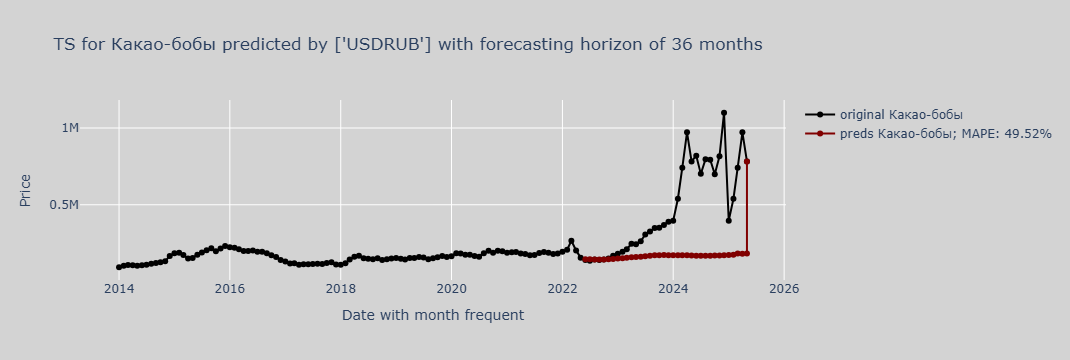

    Stimuli Crops_norm_sum
0               308.061621
1               305.990018
2               304.840574
3               304.451794
4               305.715021
5               308.583030
6               312.045774
7               316.972682
8               321.597610
9               328.372045
10              333.840147
11              338.536936
12              341.655146
13              348.598213
14              356.252881
15              361.010675
16              364.071898
17              366.521335
18              364.044212
19              363.210884
20              362.107206
21              361.376698
22              361.251844
23              359.183887
24              355.985620
25              354.513487
26              354.468183
27              356.359025
28              358.175225
29              359.655995
30              361.576499
31              365.528196
32              370.278479
33              386.818210
34              384.694071
35              388.485345


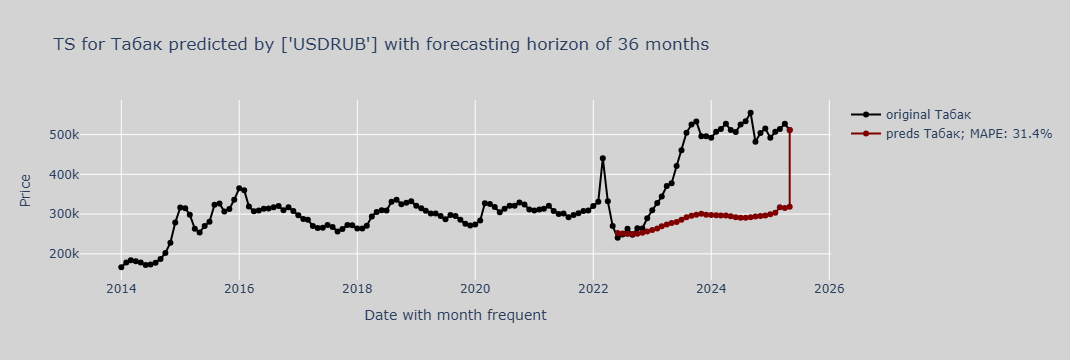

    dip_norm_sum
0     589.526340
1     584.917473
2     578.562442
3     568.667461
4     562.348739
5     552.470190
6     541.766404
7     531.468520
8     527.278169
9     526.044893
10    523.520076
11    514.565763
12    508.255748
13    505.472086
14    504.621094
15    504.080208
16    505.126819
17    510.310092
18    517.543466
19    533.126728
20    563.762949
21    602.175861
22    638.752000
23    671.406952
24    712.778873
25    766.771881
26    816.594137
27    862.281933
28    945.556565
29   1057.673659
30   1175.445590
31   1282.363023
32   1350.759524
33   1451.353965
34   1562.990614
35   1616.853207


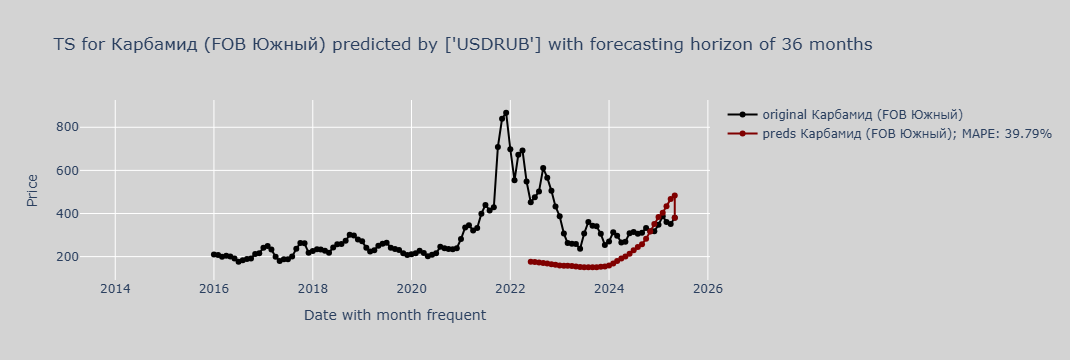

    dip_norm_sum
0     589.526340
1     584.917473
2     578.562442
3     568.667461
4     562.348739
5     552.470190
6     541.766404
7     531.468520
8     527.278169
9     526.044893
10    523.520076
11    514.565763
12    508.255748
13    505.472086
14    504.621094
15    504.080208
16    505.126819
17    510.310092
18    517.543466
19    533.126728
20    563.762949
21    602.175861
22    638.752000
23    671.406952
24    712.778873
25    766.771881
26    816.594137
27    862.281933
28    945.556565
29   1057.673659
30   1175.445590
31   1282.363023
32   1350.759524
33   1451.353965
34   1562.990614
35   1616.853207


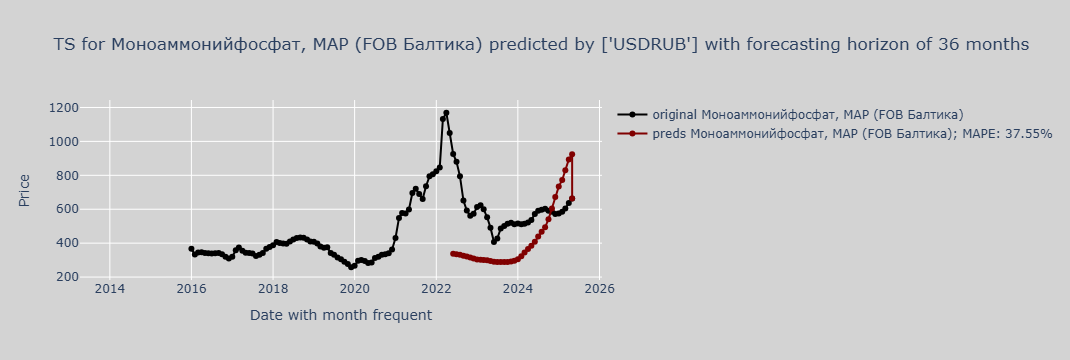

    dip_norm_sum
0     589.526340
1     584.917473
2     578.562442
3     568.667461
4     562.348739
5     552.470190
6     541.766404
7     531.468520
8     527.278169
9     526.044893
10    523.520076
11    514.565763
12    508.255748
13    505.472086
14    504.621094
15    504.080208
16    505.126819
17    510.310092
18    517.543466
19    533.126728
20    563.762949
21    602.175861
22    638.752000
23    671.406952
24    712.778873
25    766.771881
26    816.594137
27    862.281933
28    945.556565
29   1057.673659
30   1175.445590
31   1282.363023
32   1350.759524
33   1451.353965
34   1562.990614
35   1616.853207


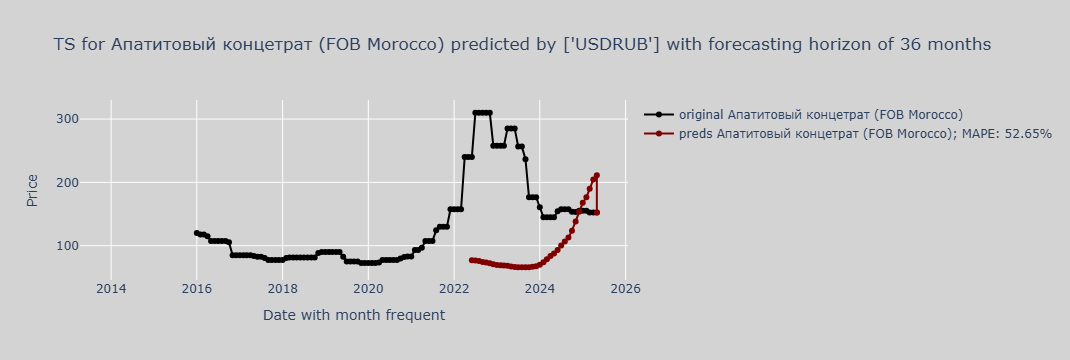

    dip_norm_sum
0     589.526340
1     584.917473
2     578.562442
3     568.667461
4     562.348739
5     552.470190
6     541.766404
7     531.468520
8     527.278169
9     526.044893
10    523.520076
11    514.565763
12    508.255748
13    505.472086
14    504.621094
15    504.080208
16    505.126819
17    510.310092
18    517.543466
19    533.126728
20    563.762949
21    602.175861
22    638.752000
23    671.406952
24    712.778873
25    766.771881
26    816.594137
27    862.281933
28    945.556565
29   1057.673659
30   1175.445590
31   1282.363023
32   1350.759524
33   1451.353965
34   1562.990614
35   1616.853207


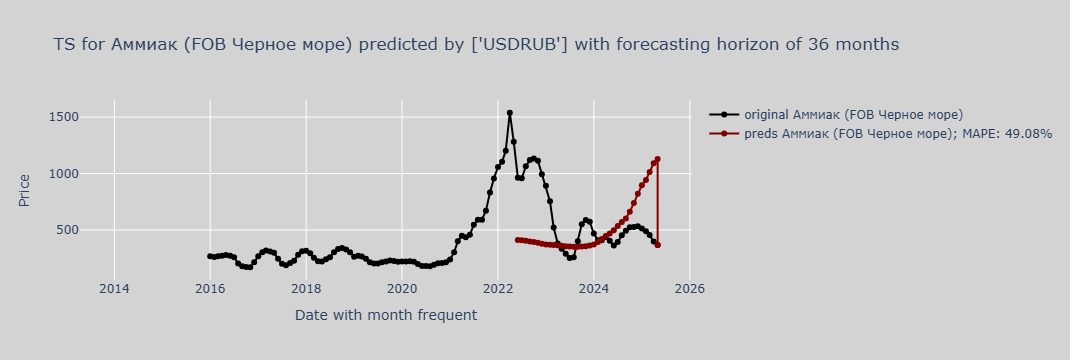

    dip_norm_sum
0     589.526340
1     584.917473
2     578.562442
3     568.667461
4     562.348739
5     552.470190
6     541.766404
7     531.468520
8     527.278169
9     526.044893
10    523.520076
11    514.565763
12    508.255748
13    505.472086
14    504.621094
15    504.080208
16    505.126819
17    510.310092
18    517.543466
19    533.126728
20    563.762949
21    602.175861
22    638.752000
23    671.406952
24    712.778873
25    766.771881
26    816.594137
27    862.281933
28    945.556565
29   1057.673659
30   1175.445590
31   1282.363023
32   1350.759524
33   1451.353965
34   1562.990614
35   1616.853207


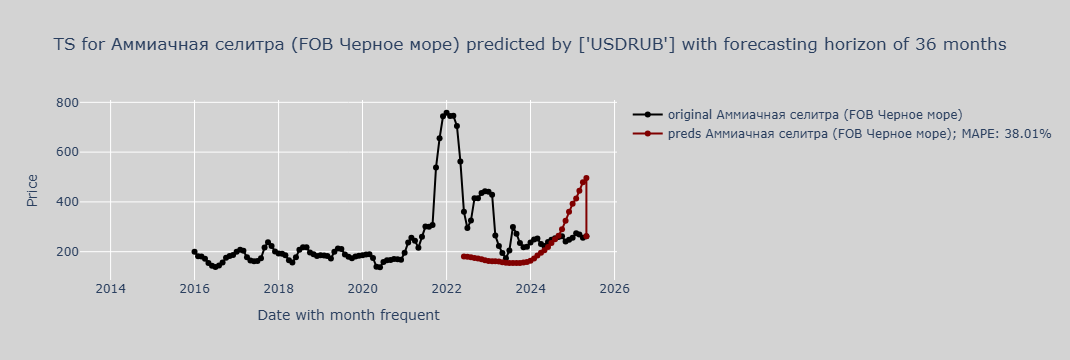

    dip_norm_sum
0     589.526340
1     584.917473
2     578.562442
3     568.667461
4     562.348739
5     552.470190
6     541.766404
7     531.468520
8     527.278169
9     526.044893
10    523.520076
11    514.565763
12    508.255748
13    505.472086
14    504.621094
15    504.080208
16    505.126819
17    510.310092
18    517.543466
19    533.126728
20    563.762949
21    602.175861
22    638.752000
23    671.406952
24    712.778873
25    766.771881
26    816.594137
27    862.281933
28    945.556565
29   1057.673659
30   1175.445590
31   1282.363023
32   1350.759524
33   1451.353965
34   1562.990614
35   1616.853207


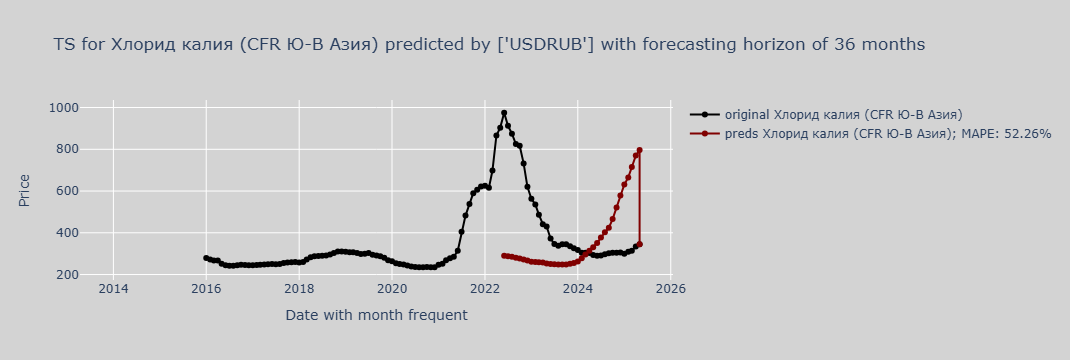

    bump_norm_sum
0      567.677825
1      562.776550
2      553.766272
3      545.747825
4      538.540050
5      534.512248
6      532.209935
7      531.794936
8      526.456406
9      511.787144
10     492.830006
11     474.116198
12     461.766123
13     447.681517
14     443.740061
15     441.269489
16     441.306869
17     444.675178
18     451.790811
19     464.074561
20     476.771657
21     490.630294
22     500.159680
23     507.715809
24     510.030429
25     515.681368
26     527.754861
27     533.567111
28     535.253598
29     541.859312
30     547.254365
31     553.959433
32     562.227928
33     573.335482
34     585.990518
35     598.032250


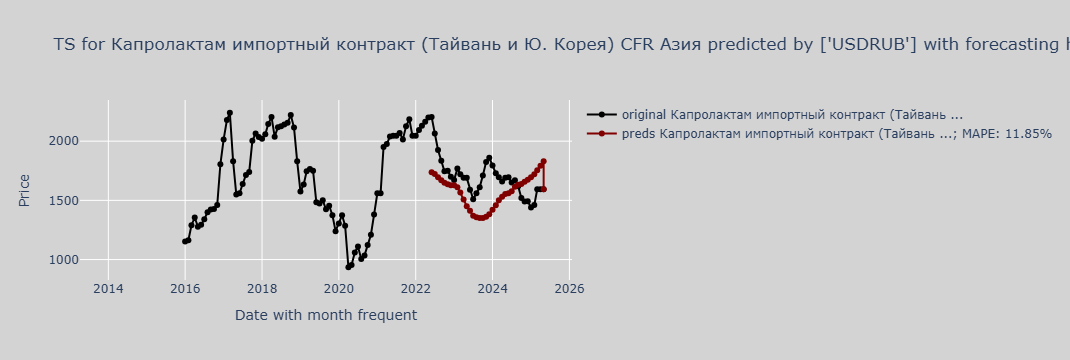

    bump_norm_sum
0      567.677825
1      562.776550
2      553.766272
3      545.747825
4      538.540050
5      534.512248
6      532.209935
7      531.794936
8      526.456406
9      511.787144
10     492.830006
11     474.116198
12     461.766123
13     447.681517
14     443.740061
15     441.269489
16     441.306869
17     444.675178
18     451.790811
19     464.074561
20     476.771657
21     490.630294
22     500.159680
23     507.715809
24     510.030429
25     515.681368
26     527.754861
27     533.567111
28     535.253598
29     541.859312
30     547.254365
31     553.959433
32     562.227928
33     573.335482
34     585.990518
35     598.032250


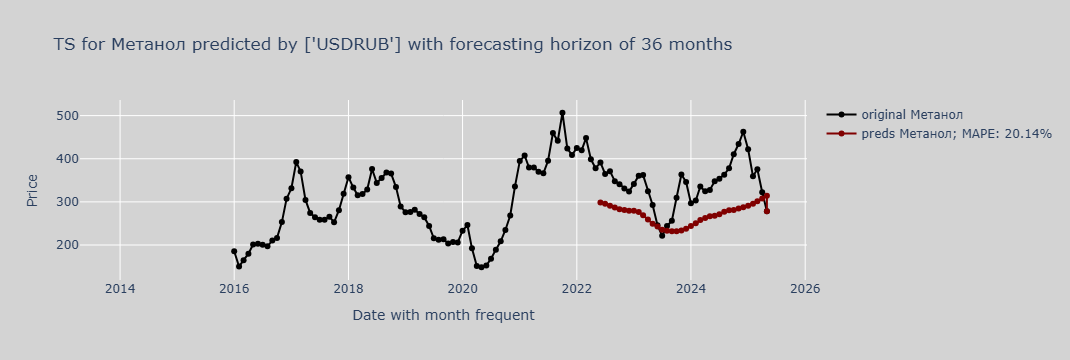

    bump_norm_sum
0      567.677825
1      562.776550
2      553.766272
3      545.747825
4      538.540050
5      534.512248
6      532.209935
7      531.794936
8      526.456406
9      511.787144
10     492.830006
11     474.116198
12     461.766123
13     447.681517
14     443.740061
15     441.269489
16     441.306869
17     444.675178
18     451.790811
19     464.074561
20     476.771657
21     490.630294
22     500.159680
23     507.715809
24     510.030429
25     515.681368
26     527.754861
27     533.567111
28     535.253598
29     541.859312
30     547.254365
31     553.959433
32     562.227928
33     573.335482
34     585.990518
35     598.032250


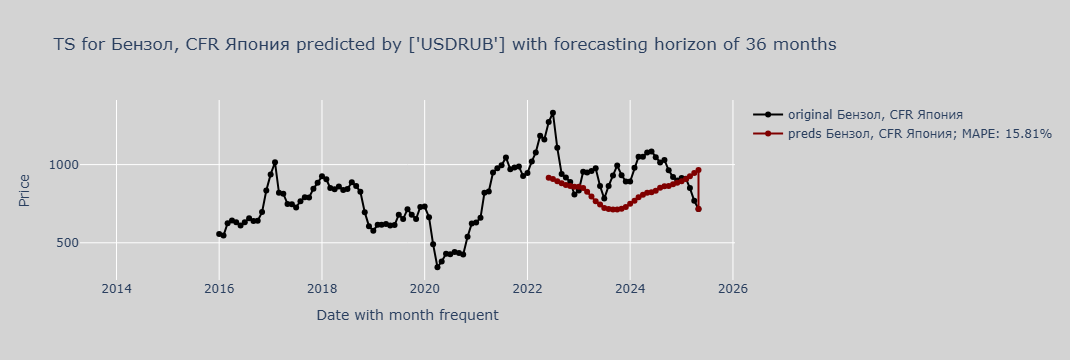

    bump_norm_sum
0      567.677825
1      562.776550
2      553.766272
3      545.747825
4      538.540050
5      534.512248
6      532.209935
7      531.794936
8      526.456406
9      511.787144
10     492.830006
11     474.116198
12     461.766123
13     447.681517
14     443.740061
15     441.269489
16     441.306869
17     444.675178
18     451.790811
19     464.074561
20     476.771657
21     490.630294
22     500.159680
23     507.715809
24     510.030429
25     515.681368
26     527.754861
27     533.567111
28     535.253598
29     541.859312
30     547.254365
31     553.959433
32     562.227928
33     573.335482
34     585.990518
35     598.032250


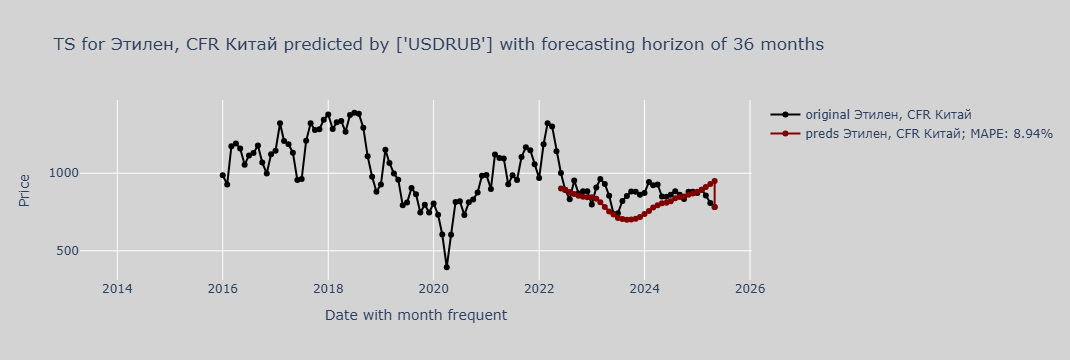

    Инфляция - Рост индекса цен производителей (RUB, eop PPI),
0                                             0.00541          
1                                             0.00463          
2                                             0.00257          
3                                             0.00388          
4                                             0.00611          
5                                             0.00798          
6                                             0.00885          
7                                             0.00541          
8                                             0.00100          
9                                             0.00212          
10                                            0.00317          
11                                           -0.00208          
12                                           -0.00768          
13                                           -0.00139          
14                                      

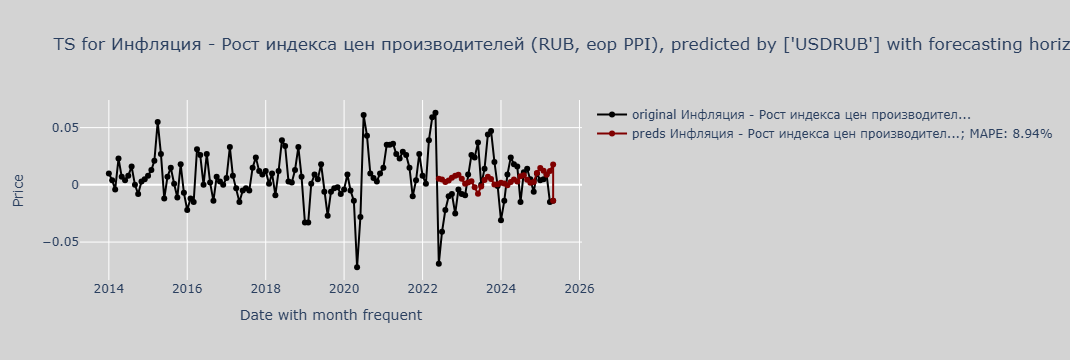

    Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),
0                                               0.178                                
1                                               0.182                                
2                                               0.174                                
3                                               0.168                                
4                                               0.124                                
5                                               0.153                                
6                                               0.191                                
7                                               0.168                                
8                                               0.193                                
9                                               0.201                                
10                                              0.100 

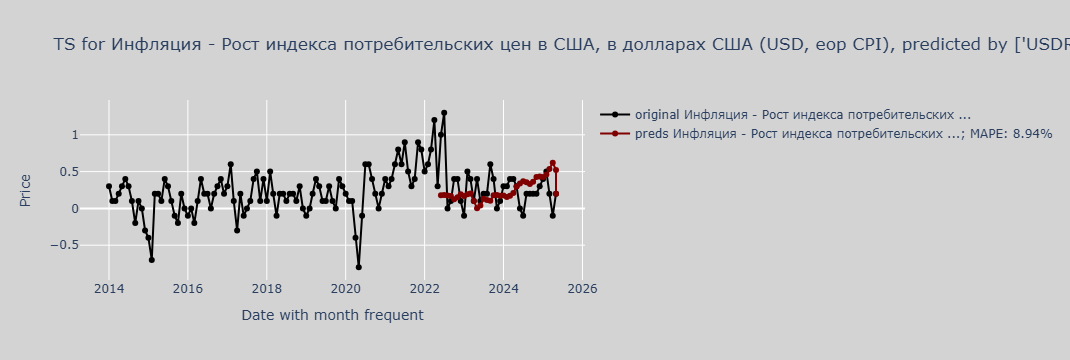

    Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),
0                                             0.00200                                
1                                             0.00182                                
2                                             0.00186                                
3                                             0.00172                                
4                                             0.00132                                
5                                             0.00160                                
6                                             0.00165                                
7                                             0.00141                                
8                                             0.00181                                
9                                             0.00093                                
10                                            0.00111 

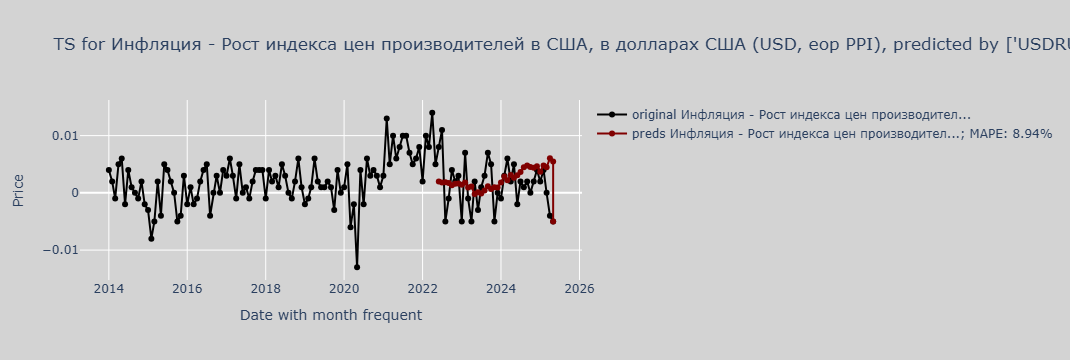

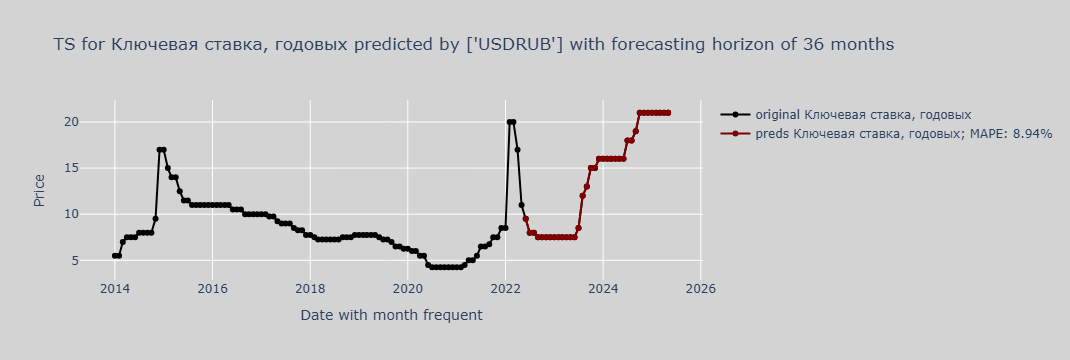

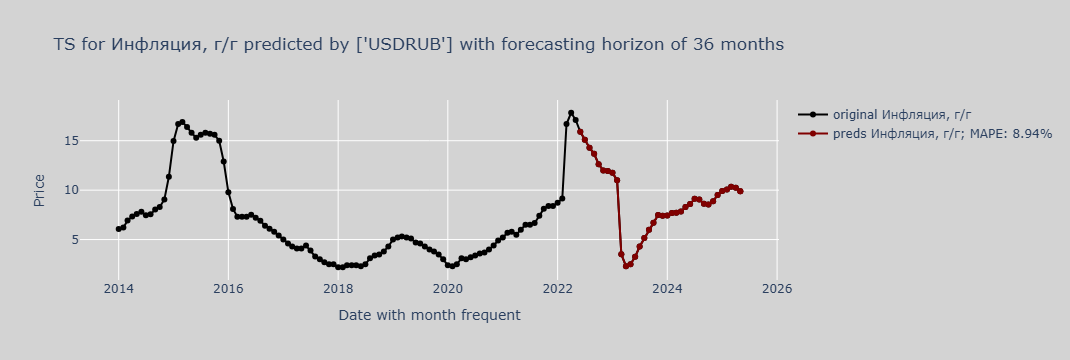

    USDRUB_norm_sum
0        179.378786
1        178.147667
2        179.485146
3        180.360082
4        180.537537
5        180.380796
6        180.461806
7        180.885629
8        182.502740
9        188.531181
10       192.312200
11       194.130502
12       194.519013
13       196.544985
14       198.495288
15       202.112725
16       204.926531
17       205.610770
18       204.363907
19       205.138336
20       204.984017
21       204.093476
22       204.221959
23       203.131444
24       201.537765
25       202.183965
26       203.484749
27       203.467283
28       202.606506
29       202.690998
30       205.123729
31       209.467182
32       212.197506
33       226.264415
34       221.226538
35       214.362255


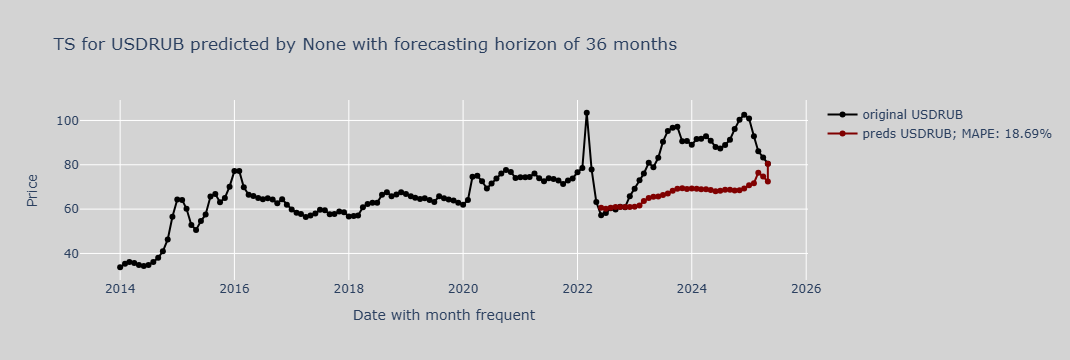

In [6]:
from sklearn.metrics import mean_absolute_percentage_error as mape


answer_last = pd.DataFrame([])
df_updated.columns = [col_name.replace("/", " ") for col_name in df_updated.columns]
mape_values = {}
processed_columns = []
for col in CATEGORY_MAP.keys():
    is_predicting_macro = col in macro_updated.columns
    df_for_col = macro_updated if is_predicting_macro else df_updated
    if col in ('Подсолнечное масло (наливом) не бутилированное, не'):
        continue
    category_to_pred = CATEGORY_MAP.get(col, "")
    if category_to_pred == "":
        continue

    cluster_preds, ts_prediction = get_prediction_for_ts(df_updated,
                                                          models[category_to_pred],
                                                          col,
                                                          MODEL_NAME_FOR_FORECASTER,
                                                          macro_updated,
                                                          past_idx,
                                                          future_idx,
                                                          CATEGORY_MAP,
                                                          BEST_PREDICTORS_FOR_INDEX,
                                                          TARGET_COL_SUFFIX,
                                                          FUTURE_FORECASTER_TS_NAME,
                                                          FUTURE_FORECASTER_TS_VALUES,
                                                          USE_FUTURE_COV,
                                                          PREDICTION_HORIZON,
                                                          IS_BACKTEST,
                                                          PREDICTOR_LAG,
                                                          new_dates
                                                        )
    # print(ts_prediction.index)
    processed_columns.append(col)
    answer_last = pd.concat([answer_last, ts_prediction], axis=1)
    if not is_predicting_macro:
        mape_val = mape(df_for_col.loc[ts_prediction.index][col], ts_prediction[f"{col}_preds"]) if IS_BACKTEST else -1
    mape_values[col] = mape_val
    plot_graphics_for_each_ts(df_for_col[f"{col}"],
                          ts_prediction[f"{col}_preds"],
                          None,
                          col,
                          mape_val,
                          -1,
                          BEST_PREDICTORS_FOR_INDEX[CATEGORY_MAP[col]],
                          "",
                          forecasting_horizon=PREDICTION_HORIZON)
answer_last.to_excel(f"prediction_up_to_2025_{MODEL_NAME_FOR_FORECASTER}_new_{BACKTEST_PREDICTION_RANGE}.xlsx")
pd.DataFrame([mape_values]).to_excel(f"mape_up_to_2025_{MODEL_NAME_FOR_FORECASTER}_new_{BACKTEST_PREDICTION_RANGE}.xlsx")

In [10]:
df_for_col.index[-1]
df_for_col.iloc[-1, 0] if df_for_col.shape[1] == 1 else df_for_col.iloc[-1]

Unnamed: 0                            2025-05-01
USDRUB                                      80.5
Кукуруза                                10.39729
Молоко сырое                            34.34781
Мясо птицы бройлеров в живом весе      116.32176
                                         ...    
Метанол_norm                          150.080906
Бензол, CFR Япония_norm               128.896882
Этилен, CFR Китай_norm                 79.240506
dip_norm_sum                          882.086399
bump_norm_sum                         496.408711
Name: 2025-05-01 00:00:00, Length: 110, dtype: object

In [8]:
df_for_col

,Unnamed: 0,USDRUB,Кукуруза,Молоко сырое,Мясо птицы бройлеров в живом весе,Мясо крупного рогатого скота в живом весе,Подсолнечник,Пшеница 1-го класса,Пшеница 3-го класса,Пшеница 5-го класса,...,Апатитовый концетрат (FOB Morocco)_norm,Аммиак (FOB Черное море)_norm,Аммиачная селитра (FOB Черное море)_norm,Хлорид калия (CFR Ю-В Азия)_norm,Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия_norm,Метанол_norm,"Бензол, CFR Япония_norm","Этилен, CFR Китай_norm",dip_norm_sum,bump_norm_sum
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,2014-01-01,33.7787,5.10830,19.22489,53.78150,71.50234,9.354690,6.280540,6.643890,6.301820,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-02-01,2014-02-01,35.3147,5.52927,20.10432,53.73414,70.26937,8.948730,6.703800,6.835350,6.172930,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-03-01,2014-03-01,36.1269,5.55814,20.39963,54.36590,70.87358,10.374500,7.572830,7.188960,6.005710,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-01,2014-04-01,35.6723,6.12138,20.49657,55.41361,71.26701,10.977020,8.143270,7.549900,6.583600,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-05-01,2014-05-01,34.8429,6.69644,20.06417,58.83824,73.39434,11.599550,10.168250,8.128110,7.100440,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01,2025-01-01,100.8700,9.88611,33.78862,122.24555,151.65117,26.193182,10.036364,13.019091,9.183409,...,129.166667,192.681445,128.300940,107.623318,124.891587,227.669903,164.568345,88.438819,880.486647,605.568654
2025-02-01,2025-02-01,92.8200,10.02863,34.29801,117.15675,148.81030,26.215909,9.886591,12.859091,9.172727,...,129.166667,183.716222,137.554859,110.762332,126.626193,193.770227,163.669065,90.464135,905.390775,574.529619
2025-03-01,2025-03-01,86.0700,10.22543,34.50990,113.32584,160.52646,26.125000,9.813273,12.474000,9.199273,...,127.083333,170.825597,134.796238,112.825112,138.190416,202.535059,152.877698,86.708861,882.452104,580.312034


In [28]:
np.mean(list(mape_values.values())) # 12

np.float64(7799302058641.274)

In [7]:
np.mean(list(mape_values.values())) # 24

np.float64(0.2355687418740066)

In [12]:
np.mean(list(mape_values.values())) # 36

np.float64(0.5130650905204059)

In [10]:
np.mean(list(mape_values.values())) # 48

np.float64(0.27050711398639565)